# Karstnet - plotting
The `karsnet` package provides useful functions to plot `networkx` graph (with position as node attributes) in 2D or 3D, and to plot in colors the nodes and / or edges according to a scalar node / edge attribute (property):
- `kn.view.plot_graph2d` : plot in 2D
- `kn.view.plot_graph3d` : plot in 3D, based on `matplotlib`
- `kn.view.pv_plot_graph` : plot in 3D, based on `pyvista`

In this notebook, some examples illustrate various functionalities on an example (real karst network of Combe Bryon, Leysin, Switzerland).

In [1]:
import networkx as nx
import numpy as np 
import matplotlib.pyplot as plt
import pyvista as pv

In [2]:
# Choose matplotlib backend
# -------------------------
# 'inline' : inline plot (non-interactive)
# 'widget' : interactive plot
# 'tk'     : plot in a pop-up window (interactive)
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
# get_ipython().run_line_magic('matplotlib', 'widget')
# get_ipython().run_line_magic('matplotlib', 'tk')

# Or simply:
# %matplotlib inline
# %matplotlib widget
# %matplotlib tk


In [3]:
import pyvista as pv

# Choose backend for pyvista with jupyter
# ---------------------------------------
pv.set_jupyter_backend('static') # static plots
# pv.set_jupyter_backend('trame')  # 3D-interactive plots

# Notes:
# -> ignored if run in a standard python shell
# -> use keyword argument "notebook=False" in Plotter() to open figure in a pop-up window

In [4]:
# requires version 1.3.0 or higher
import karstnet as kn
print(f'Karstnet version: {kn.__version__}')

Karstnet version: 1.4.6


## Prepare the example

### Load karst network
Load karst network from csv files. Note that other format are handled by karstnet.

In [6]:
# basename = f'../data/CombeBryon_csv/CombeBryon'
basename = r"C:\Users\celia\github\karstnet\data\047_Seefeldhoele_000\clean_graph_csv\047_Seefeldhoele_000"
kg = kn.from_csv(
        basename,
        suffix_nodes='_node_pos.csv', 
        suffix_edges='_edges.csv', 
        delimiter_nodes=';',  
        delimiter_edges=';',
        verbose=True)


This network contains 1 connected components
   This network contains 1 looping branch.es. 
   Tortuosity is infinite on a looping branch. 
   The looping branches are not considered for the mean tortuosity computation.

Karstnet graph successfully created from csv files !



In [7]:
# # Equivalent 
# # ----------
# # - define networkx graph
# g = kn.io.networkx_from_csv(
#         basename,
#         suffix_nodes='_node_pos.csv', 
#         suffix_edges='_edges.csv', 
#         delimiter_nodes=';',  
#         delimiter_edges=';',
#         import_node_scalar_properties=True,
#         import_edge_scalar_properties=True,
#         verbose=True)
# # - then instanciate KGraph with
# kg = kn.from_networkx(g)
# # or
# Kg = kn.KGraph(None, None, None, networkx_graph=g, verbose=True)

### Get the `networkx` graph

In [8]:
g = kg.graph

Show all node attributes (properties) and all edge attributes (properties)

In [9]:
print('List of node attributes:', kn.utils.get_node_attribute_names(g))
print('List of edge attributes:', kn.utils.get_edge_attribute_names(g))

List of node attributes: ['branch_ids_list', 'pos']
List of edge attributes: ['dip', 'azimuth', 'length2d', 'length']


### Add scalar attributes to nodes and edges for further illustrations

Add node scalar properties from a csv file: cross-sectional width ('cswidth') and height ('csheight').

In [10]:
kg.add_node_scalar_properties_from_csv(f'{basename}_node_csdim.csv')

Karstnet graph: node scalar properties successfully imported from csv file (C:\Users\celia\github\karstnet\data\047_Seefeldhoele_000\clean_graph_csv\047_Seefeldhoele_000_node_csdim.csv) !



Add a new node property from a dictionary: elevation (third component of the position)

In [11]:
# Set new node property from a dictionary
elevation = {u:g.nodes[u]['pos'][2] for u in g.nodes()}
# Attach attribute to nodes
nx.set_node_attributes(g, elevation, 'elevation')

Add a new node property with missing data (`nan` values): elevation with missing data

In [12]:
# Set new node property from a dictionary (elevation with missing data)
elevation_inc = nx.get_node_attributes(g, 'elevation')
for u in g.nodes():
    if elevation_inc[u] > 1500.0 and elevation_inc[u] < 1600.0:
        elevation_inc[u] = np.nan

# Attach attribute to nodes
nx.set_node_attributes(g, elevation_inc, 'elevation_inc')

Add new edge properties mean elevation (complete and incomplete data)

In [13]:
# Set new edge property from a dictionary (mean elevation)
mean_elevation = {e: 0.5*(g.nodes[e[0]]['pos'][2] + g.nodes[e[1]]['pos'][2]) for e in g.edges()}

# Set new edge property from a dictionary (mean elevation with missing data)
mean_elevation_inc = mean_elevation.copy()
for e in g.edges():
    if mean_elevation_inc[e] > 1500.0 and mean_elevation_inc[e] < 1600.0:
        mean_elevation_inc[e] = np.nan

# Attach attributes to edges
nx.set_edge_attributes(g, mean_elevation, 'mean_elevation')
nx.set_edge_attributes(g, mean_elevation_inc, 'mean_elevation_inc')

Show all node attributes (properties) and all edge attributes (properties)

In [14]:
print('List of node attributes:', kn.utils.get_node_attribute_names(g))
print('List of edge attributes:', kn.utils.get_edge_attribute_names(g))

List of node attributes: ['cswidth', 'csheight', 'pos', 'branch_ids_list', 'elevation_inc', 'elevation']
List of edge attributes: ['dip', 'length', 'mean_elevation_inc', 'length2d', 'azimuth', 'mean_elevation']


### Visual check - original and simplified graphs

The metod `plot` of a `karstnet.KGraph` object plots the original and simplified graphs (in 2D) in a figure of two subplots; this allows to quickly check that the data that you just loaded have been properly imported.

*Note: this function call the function `kn.view.plot_graph2d`.*

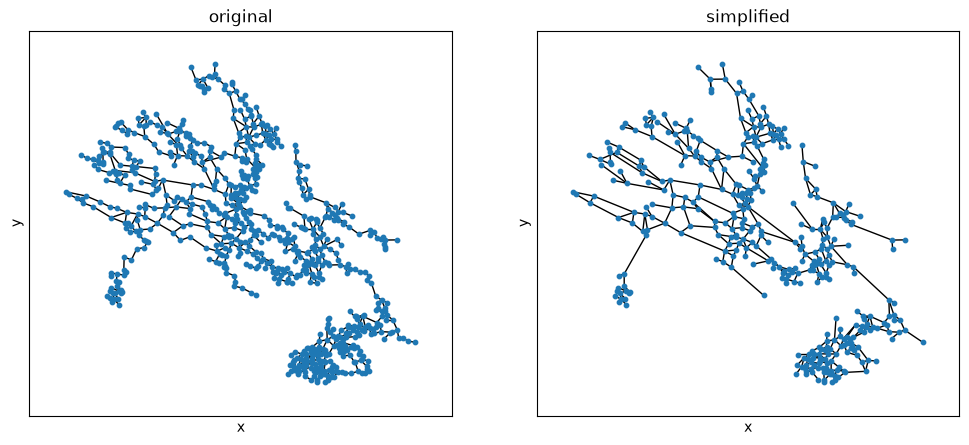

In [15]:
# Simple map view of original data (left) and simplified graph (right)
kg.plot(node_size=10)

## Plot in 2D

The method `plot2d` of a `karstnet.KGraph` object, or the function `karstnet.view.plot_graph2d`, allows to plot the original (or simplified) graph in 2D, with various options. The plot is made in the current axis of the figure (created if needed).

The plot is done by using:
- the function `networkx.draw_networkx`
- moreover, the function `networkx.draw_networkx_nodes` if a node atttribute is specified
- moreover, the function `networkx.draw_networkx_edges` if an edge atttribute is specified

The relevant keyword arguments (options) are passed to these functions.

Several projection modes onto a 2D plane are available through the parameter `proj_mode`.

Some examples are shown below; see the docs of the function `karstnet.view.plot_graph2d` for more details.

### Plot in 2D (no node / edge property) - projection in xy-section (default)

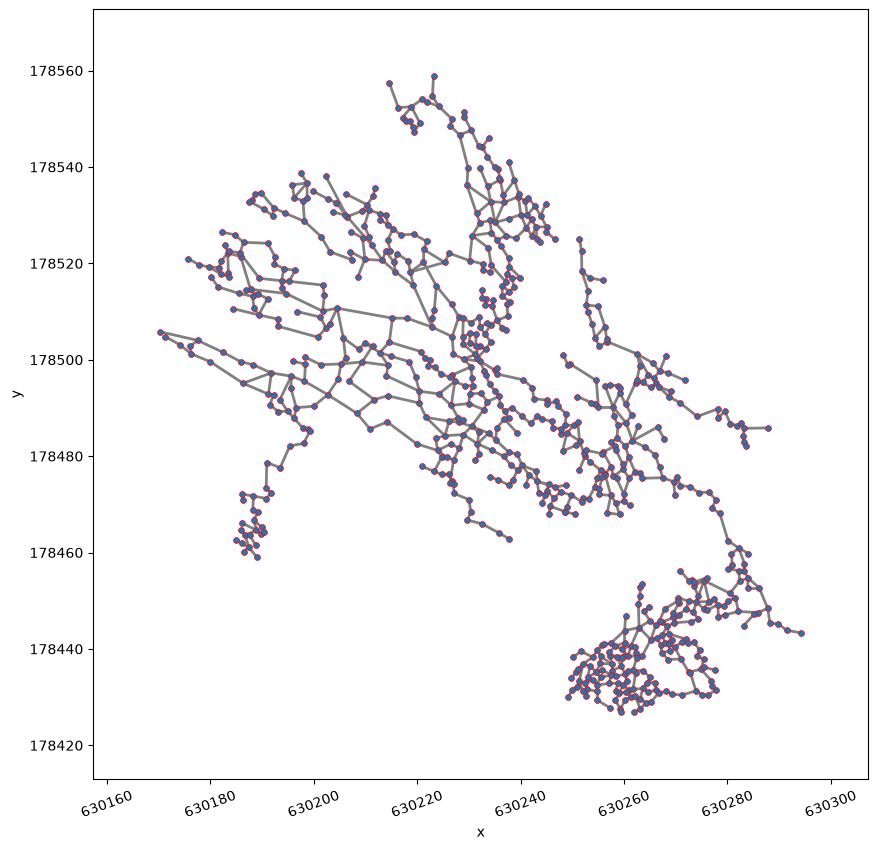

In [16]:
# Plot 2D (no node / edge property) - projection onto Oxy (default)
options = {
    'node_size'   : 18,         # node size
    'linewidths'  : 0.5,        # node border width       
    'edgecolors'  : 'red',      # node border color
    'node_color'  : 'tab:blue', # node color
    'width'       : 2,          # edge width
    'edge_color'  : 'gray',     # edge color
    'with_labels' : False,      # show node labels ?
    # 'font_size'   : 10          # font size for labels
}

plt.figure(figsize=(10, 10))

kn.view.plot_graph2d(
    g,
    plot_nodes=True, # default is True; set to False to hide nodes
    plot_edges=True, # default is True; set to False to hide edges
    show_ticks=True, 
    options_xaxis_ticks={'rotation':20},
    **options
)
# # OR:
# kg.plot2d(
#     show_ticks=True, options_xaxis_ticks={'rotation':20},
#     **options
# )

plt.show()


### Plot in 2D - plot a node property (attribute)

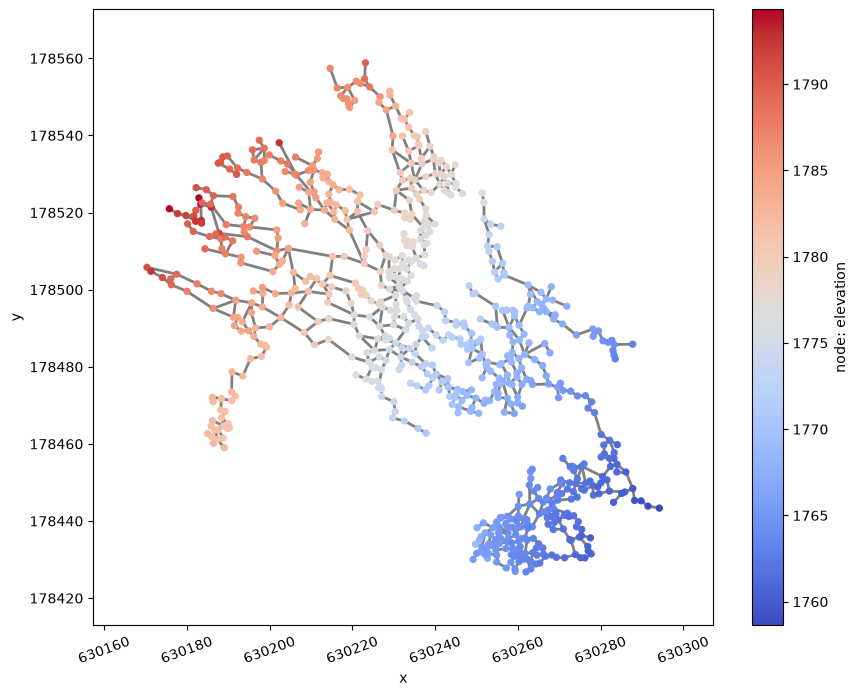

In [17]:
# Plot 2D - plot a node property (attribute) 
options = {
    'node_size'   : 18,          # node size
    # 'linewidths'  : 0,           # node border width       
    'cmap'        : 'coolwarm',  # node color map (for attribute values)
    'width'       : 2,           # edge width
    'edge_color'  : 'gray',      # edge color
    'with_labels' : False,       # show node labels ?
    # 'font_size'   : 10           # font size for labels
}

plt.figure(figsize=(10, 8))

kn.view.plot_graph2d(
    g,
    node_attr='elevation',
    show_ticks=True, 
    options_xaxis_ticks={'rotation':20},
    **options
)

plt.show()


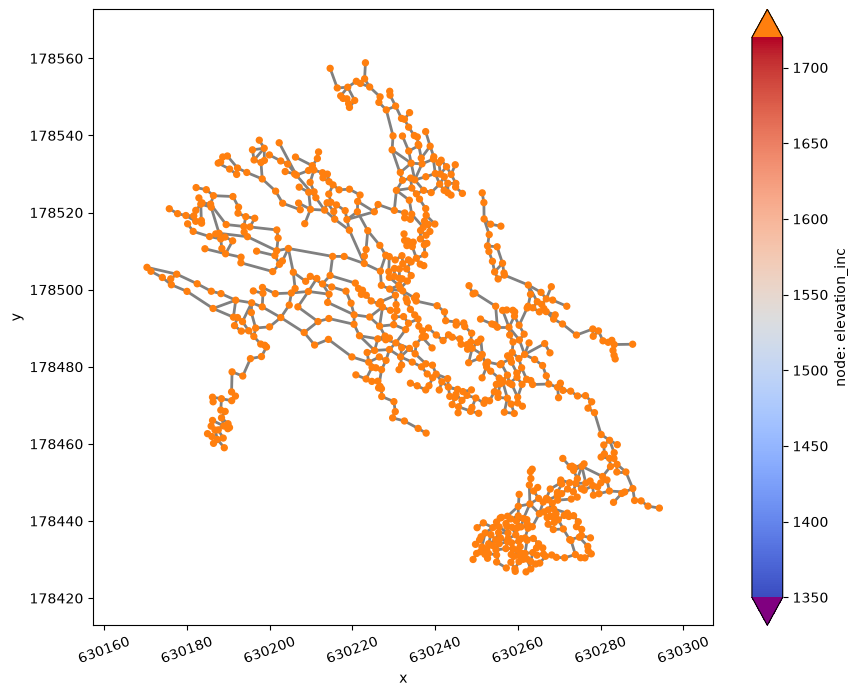

In [18]:
# Plot 2D - plot a node property (attribute) with missing data (nan) - customize color 

# Color map for node attribute
cmap = plt.get_cmap('coolwarm')
cmap.set_over('tab:orange') # color for value above upper limit 'vmax' (if specified)
cmap.set_under('purple')    # color for value below lower limit 'vmin' (if specified)
cmap.set_bad('lime')        # color for nan value (missing data) / will be overwritten by 'node_color' (if specified)

options = {
    'node_size'   : 18,          # node size
    # 'linewidths'  : 0,           # node border width       
    # 'node_color'  : 'tab:blue',  # node color (overwrite "bad color" of cmap)
    'cmap'        : cmap,        # node color map (for attribute values)
    'vmin'        : 1350,        # min value for color map (node)
    'vmax'        : 1720,        # max value for color map (node)
    'width'       : 2,           # edge width
    'edge_color'  : 'gray',      # edge color
    'with_labels' : False,       # show node labels ?
    # 'font_size'   : 10           # font size for labels
}

plt.figure(figsize=(10, 8))

kn.view.plot_graph2d(
    g,
    node_attr='elevation_inc',
    show_ticks=True, 
    options_xaxis_ticks={'rotation':20},
    options_node_colorbar={'extend':'both'},
    **options
)

plt.show()


**Specifying node size for each node**

For a graph `G`, the option `node_size` is a sequence of `G.number_of_nodes()` values given the size of every node in `G.nodes()` (even if `nodelist` is used to plot a subset of nodes).

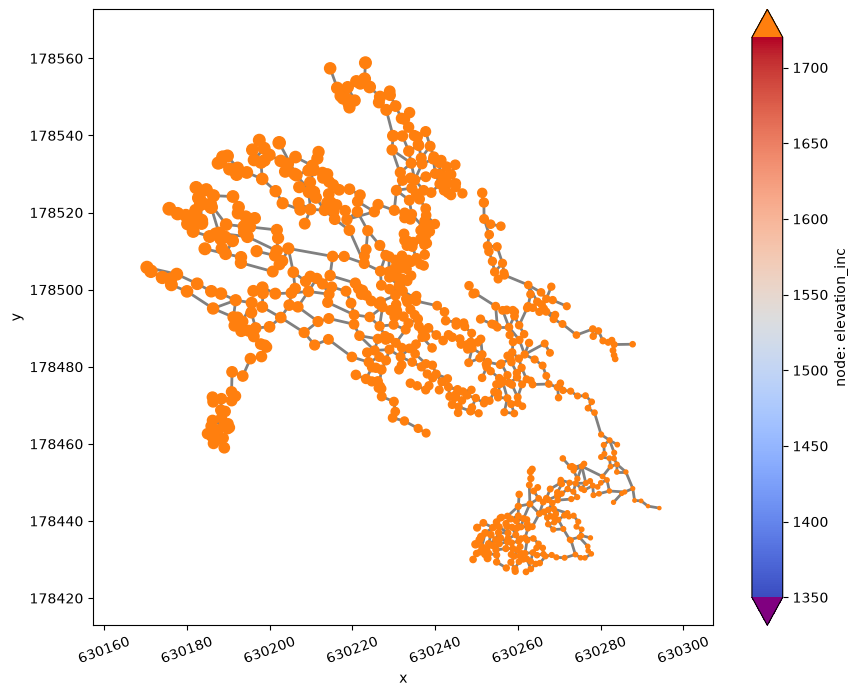

In [19]:
# Plot 2D - plot a node property (attribute) with missing data (nan) - customize color 

# Color map for node attribute
cmap = plt.get_cmap('coolwarm')
cmap.set_over('tab:orange') # color for value above upper limit 'vmax' (if specified)
cmap.set_under('purple')    # color for value below lower limit 'vmin' (if specified)
cmap.set_bad('lime')        # color for nan value (missing data) / will be overwritten by 'node_color' (if specified)

# Set custom node size according to the node property
a = nx.get_node_attributes(g, 'elevation_inc', default=np.nan)
a = np.asarray(list(a.values()))
a_min = np.nanmin(a)
a_max = np.nanmax(a)
size_min = 5
size_max = 80
size_nan = 1
t = (size_max - size_min) / (a_max - a_min)
node_size = np.full(g.number_of_nodes(), size_nan, dtype=float)
node_size[~np.isnan(a)] = size_min + (a[~np.isnan(a)] - a_min) * t

options = {
    'node_size'   : node_size,          # node size
    # 'linewidths'  : 0,           # node border width       
    # 'node_color'  : 'tab:blue',  # node color (overwrite "bad color" of cmap)
    'cmap'        : cmap,        # node color map (for attribute values)
    'vmin'        : 1350,        # min value for color map (node)
    'vmax'        : 1720,        # max value for color map (node)
    'width'       : 2,           # edge width
    'edge_color'  : 'gray',      # edge color
    'with_labels' : False,       # show node labels ?
    # 'font_size'   : 10           # font size for labels
}

plt.figure(figsize=(10, 8))

kn.view.plot_graph2d(
    g,
    node_attr='elevation_inc',
    show_ticks=True, 
    options_xaxis_ticks={'rotation':20},
    options_node_colorbar={'extend':'both'},
    **options
)

plt.show()


### Plot in 2D - plot an edge property (attribute)

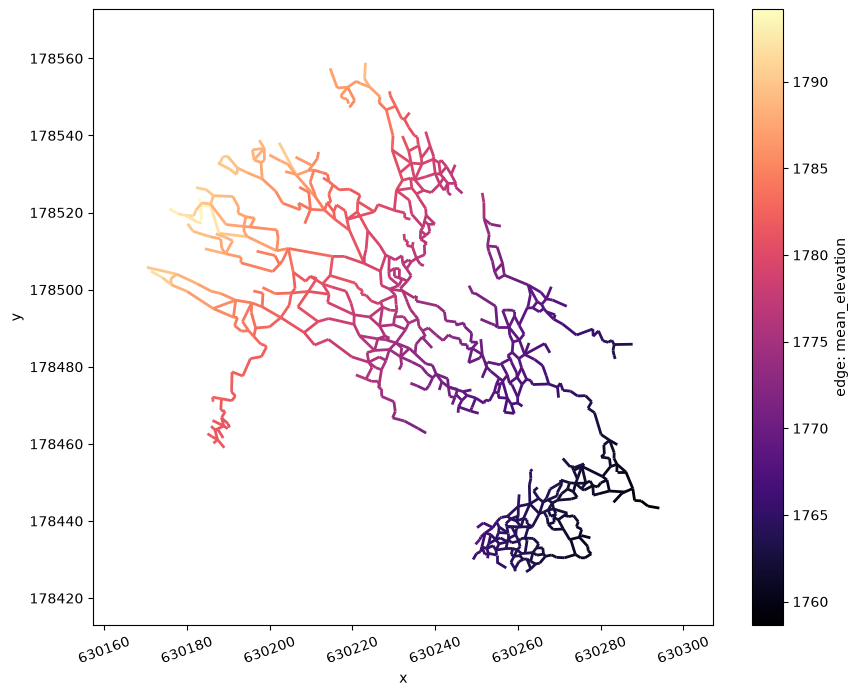

In [20]:
# Plot 2D - plot an edge property (attribute) 
options = {
    'width'       : 2,          # edge width
    'edge_cmap'   : 'magma',    # edge color map (for attribute values)
    'with_labels' : False,      # show node labels ?
    # 'font_size'   : 10        # font size for labels
}

plt.figure(figsize=(10, 8))

kn.view.plot_graph2d(
    g,
    plot_nodes=False, # hide nodes
    edge_attr='mean_elevation',
    show_ticks=True, 
    options_xaxis_ticks={'rotation':20},
    **options
)

plt.show()


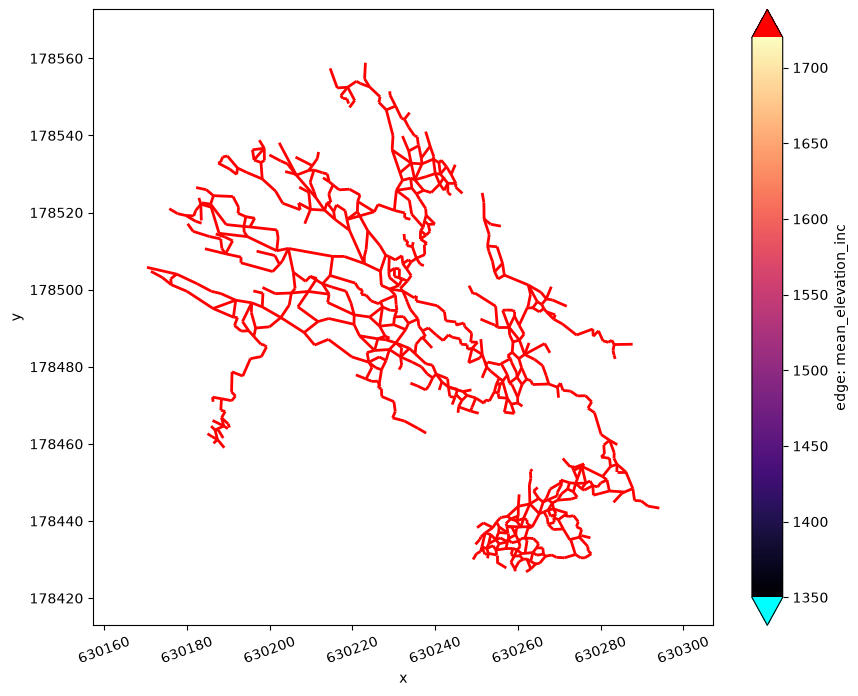

In [21]:
# Plot 2D - plot an edge property (attribute) with missing data (nan) - customize color 

# Color map for edge attribute
edge_cmap = plt.get_cmap('magma')
edge_cmap.set_over('red')        # color for value above upper limit 'edge_vmax' (if specified)
edge_cmap.set_under('cyan')      # color for value below lower limit 'edge_vmin' (if specified)
edge_cmap.set_bad('palegreen')   # color for nan value (missing data) / will be overwritten by 'edge_color' (if specified)

options = {
    'width'       : 2,           # edge width
    # 'edge_color'  : 'gray',      # edge color (overwrite "bad color" of edge_cmap)
    'edge_cmap'   : edge_cmap,   # edge color map (for attribute values)
    'edge_vmin'   : 1350,        # min value for color map (edge)
    'edge_vmax'   : 1720,        # max value for color map (edge)
    'with_labels' : False,       # show node labels ?
    # 'font_size'   : 10           # font size for labels
}

plt.figure(figsize=(10, 8))

kn.view.plot_graph2d(
    g,
    plot_nodes=False, # hide nodes
    edge_attr='mean_elevation_inc',
    show_ticks=True, 
    options_xaxis_ticks={'rotation':20},
    options_edge_colorbar={'extend':'both'},
    **options
)

plt.show()


### Plot in 2D - plot node and edge properties (attributes)

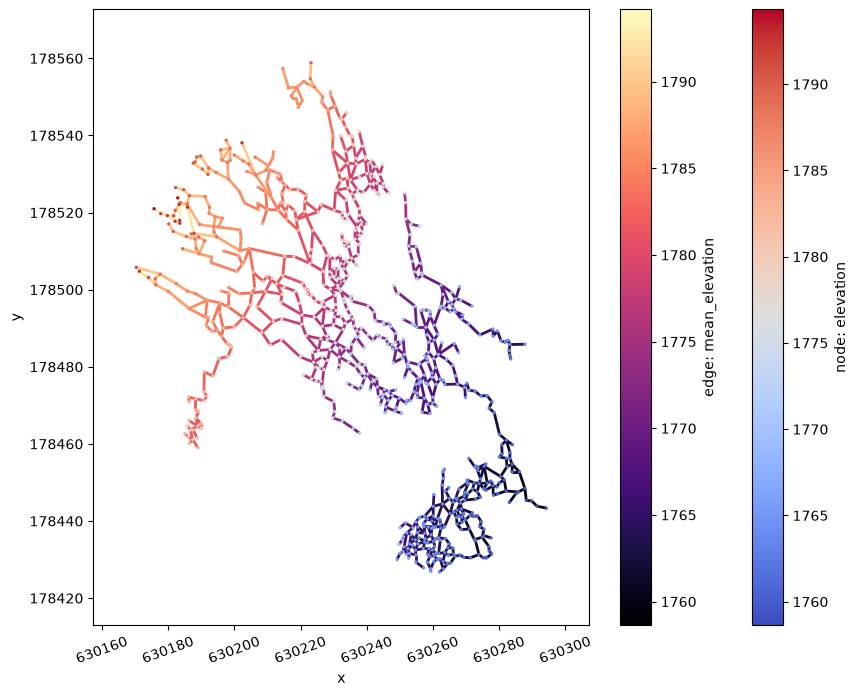

In [22]:
# Plot 2D - plot node and edge properties (attributes)

options = {
    'node_size'   : 2,           # node size
    # 'linewidths'  : 0,           # node border width       
    'cmap'        : 'coolwarm',  # node color map (for attribute values)
    'width'       : 2,           # edge width
    'edge_cmap'   : 'magma',     # edge color map (for attribute values)
    'with_labels' : False,       # show node labels ?
    # 'font_size'   : 10           # font size for labels
}

plt.figure(figsize=(10, 8))

kn.view.plot_graph2d(
    g,
    node_attr='elevation',
    edge_attr='mean_elevation',
    show_ticks=True, 
    options_xaxis_ticks={'rotation':20},
    **options
)

plt.show()


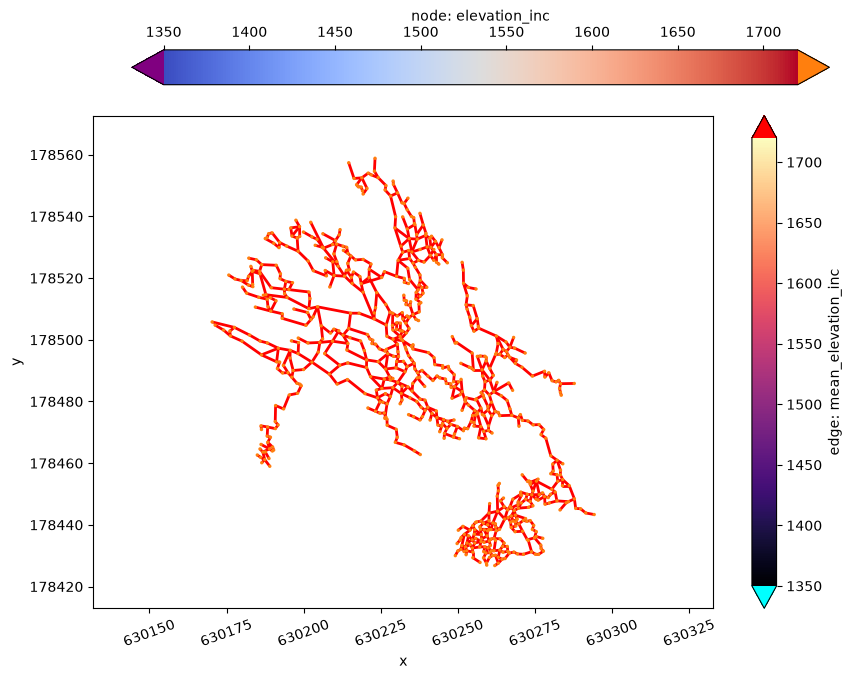

In [23]:
# Plot 2D - plot node and edge properties with missing data (nan) - customize color 

# Color map for node attribute
cmap = plt.get_cmap('coolwarm')
cmap.set_over('tab:orange') # color for value above upper limit 'vmax' (if specified)
cmap.set_under('purple')    # color for value below lower limit 'vmin' (if specified)
cmap.set_bad('lime')        # color for nan value (missing data) / will be overwritten by 'node_color' (if specified)

# Color map for edge attribute
edge_cmap = plt.get_cmap('magma')
edge_cmap.set_over('red')        # color for value above upper limit 'edge_vmax' (if specified)
edge_cmap.set_under('cyan')      # color for value below lower limit 'edge_vmin' (if specified)
edge_cmap.set_bad('palegreen')   # color for nan value (missing data) / will be overwritten by 'edge_color' (if specified)

options = {
    'node_size'   : 2,           # node size
    # 'linewidths'  : 0,           # node border width       
    # 'node_color'  : 'tab:blue',  # node color (overwrite "bad color" of cmap)
    'cmap'        : cmap,        # node color map (for attribute values)
    'vmin'        : 1350,        # min value for color map (node)
    'vmax'        : 1720,        # max value for color map (node)
    'width'       : 2,           # edge width
    # 'edge_color'  : 'gray',      # edge color (overwrite "bad color" of edge_cmap)
    'edge_cmap'   : edge_cmap,   # edge color map (for attribute values)
    'edge_vmin'   : 1350,        # min value for color map (edge)
    'edge_vmax'   : 1720,        # max value for color map (edge)
    'with_labels' : False,       # show node labels ?
    # 'font_size'   : 10         # font size for labels
}

plt.figure(figsize=(10, 8))

kn.view.plot_graph2d(
    g,
    node_attr='elevation_inc',
    edge_attr='mean_elevation_inc',
    show_ticks=True, 
    options_xaxis_ticks={'rotation':20},
    options_node_colorbar={'extend':'both', 'shrink':0.9, 'location':'top'},
    options_edge_colorbar={'extend':'both'},
    axis_equal=True, # same scale for each axis
    **options
)

plt.show()


### Plot in 2D - projection in xy-, xz-, yz-sections

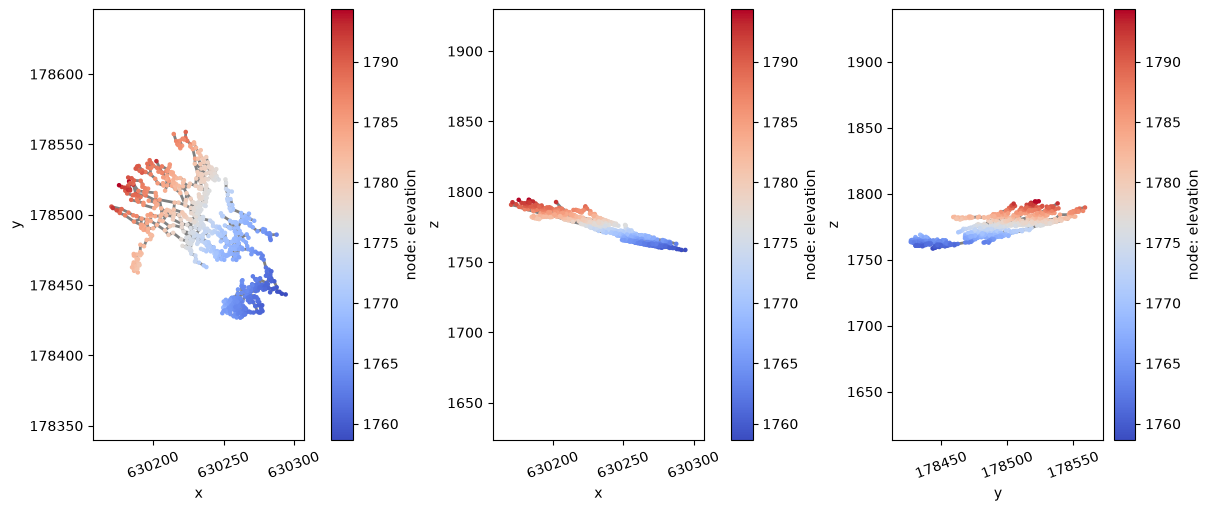

In [24]:
# Plot 2D - projection in xy-, xz-, yz-sections
# - (plot a node property (attribute))

options = {
    'node_size'   : 5,           # node size
    # 'linewidths'  : 0,           # node border width       
    'cmap'        : 'coolwarm',  # node color map (for attribute values)
    'width'       : 2,           # edge width
    'edge_color'  : 'gray',      # edge color
    'with_labels' : False,       # show node labels ?
    # 'font_size'   : 10           # font size for labels
}

plt.subplots(1, 3, constrained_layout=True, figsize=(12, 5))

plt.subplot(1, 3, 1)
kn.view.plot_graph2d(
    g,
    node_attr='elevation',
    proj_mode='xy',
    show_ticks=True, 
    options_xaxis_ticks={'rotation':20},
    axis_equal=True,    # same scale for each axis
    **options
)

plt.subplot(1, 3, 2)
kn.view.plot_graph2d(
    g,
    node_attr='elevation',
    proj_mode='xz',
    show_ticks=True, 
    options_xaxis_ticks={'rotation':20},
    axis_equal=True,    # same scale for each axis
    **options
)

plt.subplot(1, 3, 3)
kn.view.plot_graph2d(
    g,
    node_attr='elevation',
    proj_mode='yz',
    show_ticks=True, 
    options_xaxis_ticks={'rotation':20},
    axis_equal=True,    # same scale for each axis
    **options
)

plt.show()


### Plot in 2D - in principal axes (from PCA)
The principal axes system (from principal component analysis) in 3D is orthonormal and the coordinates expressed in this system are uncorrelated with decreasing variance along 1st, 2nd, and 3rd principal axes. Projection can be done in a section spanned by any two of the three principal axes. 
    

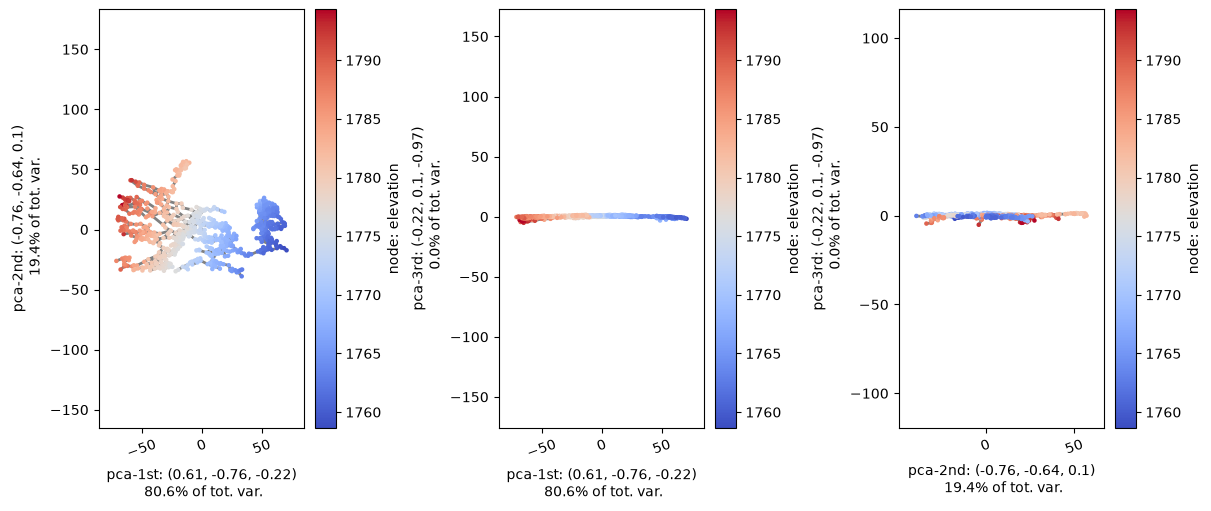

In [25]:
# Plot 2D - in principal axes (from PCA)
# - (plot a node property (attribute))

options = {
    'node_size'   : 5,           # node size
    # 'linewidths'  : 0,           # node border width       
    'cmap'        : 'coolwarm',  # node color map (for attribute values)
    'width'       : 2,           # edge width
    'edge_color'  : 'gray',      # edge color
    'with_labels' : False,       # show node labels ?
    # 'font_size'   : 10           # font size for labels
}

plt.subplots(1, 3, constrained_layout=True, figsize=(12, 5))

plt.subplot(1, 3, 1)
kn.view.plot_graph2d(
    g,
    node_attr='elevation',
    proj_mode='pca_12', # projection onto principal axes 1 and 2
    centering=True,     # centering coordinates (mean equals zero)
    show_ticks=True, 
    options_xaxis_ticks={'rotation':20},
    axis_equal=True,    # same scale for each axis
    **options
)

plt.subplot(1, 3, 2)
kn.view.plot_graph2d(
    g,
    node_attr='elevation',
    proj_mode='pca_13', # projection onto principal axes 1 and 3
    centering=True,     # centering coordinates (mean equals zero)
    show_ticks=True, 
    options_xaxis_ticks={'rotation':20},
    axis_equal=True,    # same scale for each axis
    **options
)

plt.subplot(1, 3, 3)
kn.view.plot_graph2d(
    g,
    node_attr='elevation',
    proj_mode='pca_23', # projection onto principal axes 2 and 3
    centering=True,     # centering coordinates (mean equals zero)
    show_ticks=True, 
    options_xaxis_ticks={'rotation':20},
    axis_equal=True,    # same scale for each axis
    **options
)

plt.show()


- **Note :** the function `kn.utils.pca_of_node_position` allows to get the principal axes and the variance along each principal axis.

In [26]:
pca_axes, pca_var = kn.utils.pca_of_node_position(g)
vec1, vec2, vec3 = pca_axes.T
print(f'1st principal axis, vector = {vec1}, variance = {pca_var[0]}')
print(f'2nd principal axis, vector = {vec2}, variance = {pca_var[1]}')
print(f'3rd principal axis, vector = {vec3}, variance = {pca_var[2]}')

1st principal axis, vector = [ 0.60709782 -0.7643734  -0.21717631], variance = 1606.451824360145
2nd principal axis, vector = [-0.76490168 -0.63619184  0.10092253], variance = 385.66447327328206
3rd principal axis, vector = [-0.21530829  0.10484867 -0.97090118], variance = 0.7229030038853664


### Plot 3D - based on `matplotlib`

The method `plot3d` of a `karstnet.KGraph` object, or the function `karstnet.view.plot_graph3d`, allows to plot the original (or simplified) graph in 3D, with various options. The plot is based in a 3D axes system `ax` ( instance of `mpl_toolkits.mplot3d.axes3d.Axes3D`) in the current figure; the 3D axes system is specifed (with the parameters `ax`) or created if not.

The plot is done by using:
- the function `ax.scatter` for plotting the nodes; options can be specified by the parameter `options_nodes` (dictionary)
- the function `ax.plot` for plotting the edges; options can be specified by the parameter `options_edges` (dictionary)

Principal component analysis (PCA) can be applied to plot the graph in the principal axes system (parameter `mode`).

Some examples are shown below; see the docs of the function `karstnet.view.plot_graph3d` for more details.

### Plot in 3D (matplotlib) (no node / edge property)

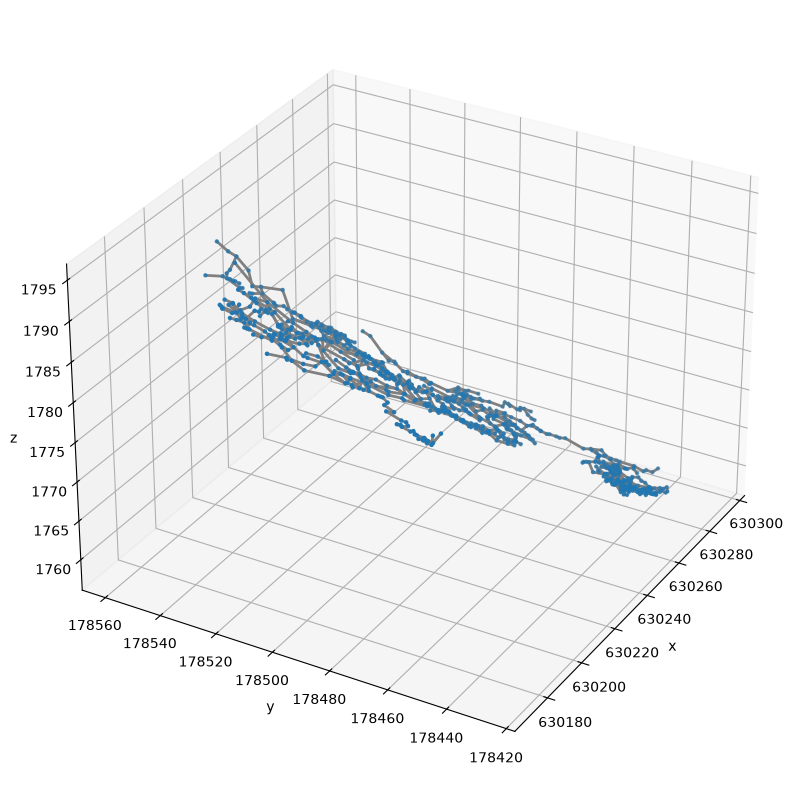

In [27]:
# Plot 3D (matplotlib) (no node / edge property)

options_nodes = {
    's'      : 5,           # node size
    'color'  : 'tab:blue',  # node color
}

options_edges = {
    'linestyle' : 'solid',  # edge line style (equivalent key: 'ls')
    'linewidth' : 2,        # edge line width (equivalent key: 'lw')
    'color'     : 'gray',   # edge color
}

plt.figure(figsize=(10, 10))

kn.view.plot_graph3d(
    g,
    plot_nodes=True, # default is True; set to False to hide nodes
    plot_edges=True, # default is True; set to False to hide edges
    options_nodes=options_nodes,
    options_edges=options_edges
)
# # OR:
# kg.plot3d(
#     options_nodes=options_nodes,
#     options_edges=options_edges
# )

plt.show()


### Plot in 3D (matplotlib) - plot a node property (attribute)

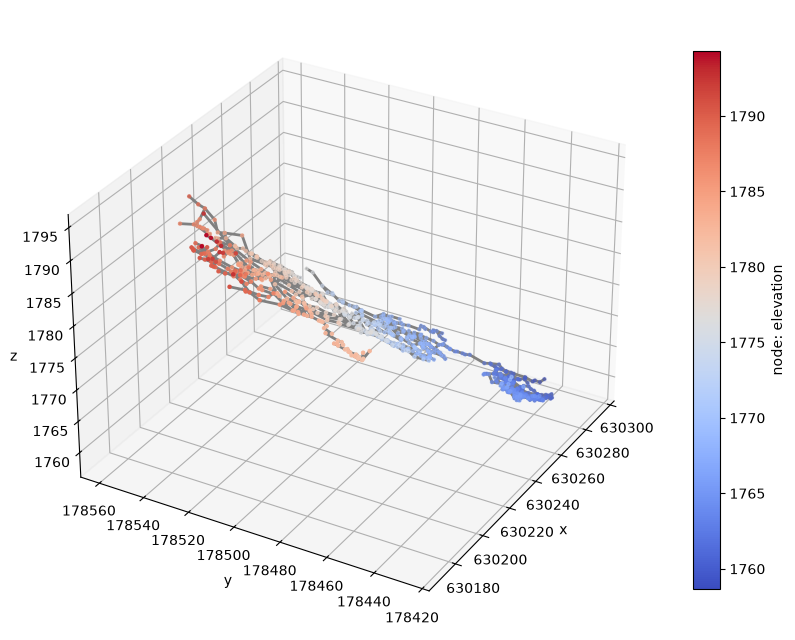

In [28]:
# Plot 3D (matplotlib) - plot a node property (attribute) 

options_nodes = {
    's'      : 5,                # node size
    'cmap'        : 'coolwarm',  # node color map (for attribute values)
}

options_edges = {
    'linestyle' : 'solid',  # edge line style (equivalent key: 'ls')
    'linewidth' : 2,        # edge line width (equivalent key: 'lw')
    'color'     : 'gray',   # edge color
}

plt.figure(figsize=(10, 10))

kn.view.plot_graph3d(
    g,
    node_attr='elevation',
    options_nodes=options_nodes,
    options_edges=options_edges,
    options_node_colorbar={'shrink':0.7}
)

plt.show()


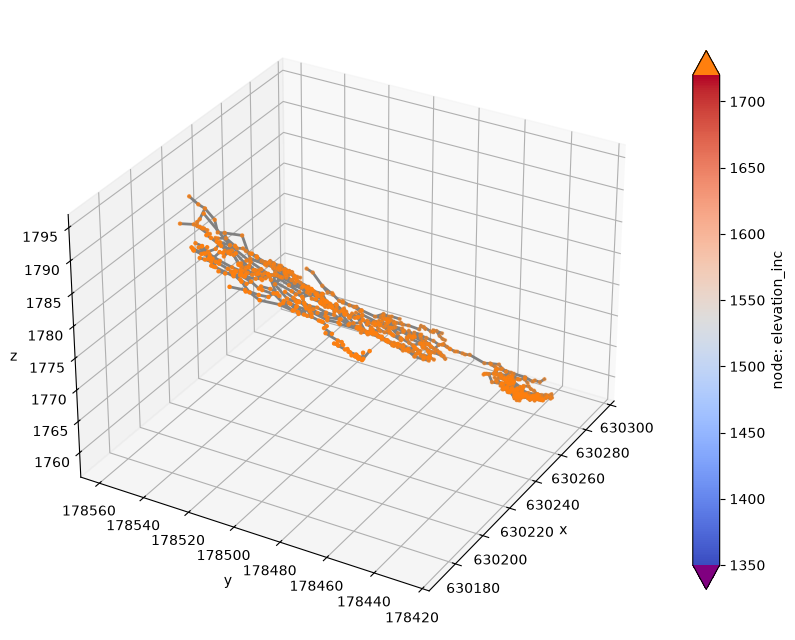

In [29]:
# Plot 3D (matplotlib) - plot a node property (attribute) with missing data (nan) - customize color 

# Color map for node attribute
cmap = plt.get_cmap('coolwarm')
cmap.set_over('tab:orange') # color for value above upper limit 'vmax' (if specified)
cmap.set_under('purple')    # color for value below lower limit 'vmin' (if specified)
cmap.set_bad('lime')        # color for nan value (missing data) / will be overwritten by 'color' (if specified)

options_nodes = {
    's'      : 5,           # node size
    # 'color'  : 'tab:blue',  # node color (overwrite "bad color" of cmap)
    'cmap'   : cmap,        # node color map (for attribute values)
    'vmin'   : 1350,        # min value for color map (node)
    'vmax'   : 1720,        # max value for color map (node)
}

options_edges = {
    'linestyle' : 'solid',  # edge line style (equivalent key: 'ls')
    'linewidth' : 2,        # edge line width (equivalent key: 'lw')
    'color'     : 'gray',   # edge color
}

plt.figure(figsize=(10, 10))

kn.view.plot_graph3d(
    g,
    node_attr='elevation_inc',
    options_nodes=options_nodes,
    options_edges=options_edges,
    options_node_colorbar={'shrink':0.7, 'extend': 'both'}
)

plt.show()


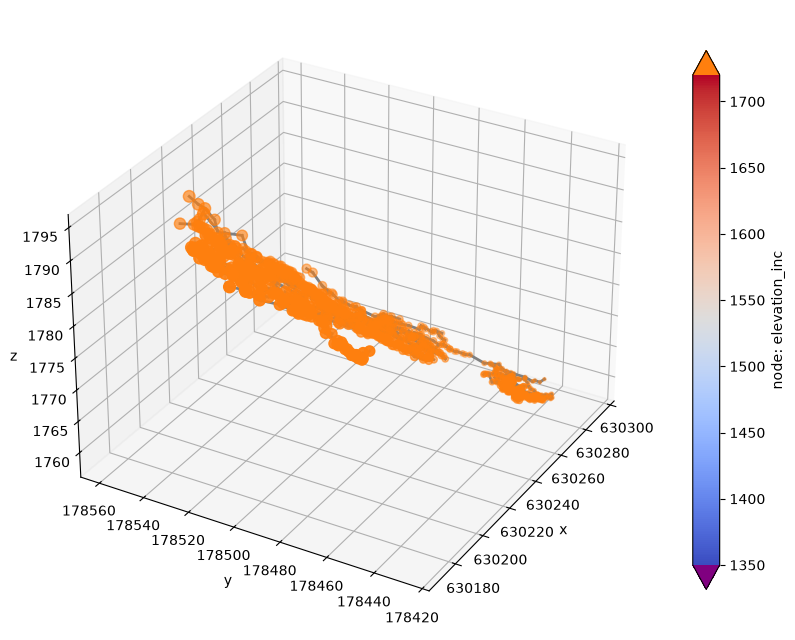

In [30]:
# Plot 3D (matplotlib) - plot a node property (attribute) with missing data (nan) - customize color 

# Color map for node attribute
cmap = plt.get_cmap('coolwarm')
cmap.set_over('tab:orange') # color for value above upper limit 'vmax' (if specified)
cmap.set_under('purple')    # color for value below lower limit 'vmin' (if specified)
cmap.set_bad('lime')        # color for nan value (missing data) / will be overwritten by 'color' (if specified)

# Set custom node size according to the node property
a = nx.get_node_attributes(g, 'elevation_inc', default=np.nan)
a = np.asarray(list(a.values()))
a_min = np.nanmin(a)
a_max = np.nanmax(a)
size_min = 5
size_max = 80
size_nan = 1
t = (size_max - size_min) / (a_max - a_min)
node_size = np.full(g.number_of_nodes(), size_nan, dtype=float)
node_size[~np.isnan(a)] = size_min + (a[~np.isnan(a)] - a_min) * t

options_nodes = {
    's'      : node_size,   # node size
    # 'color'  : 'tab:blue',  # node color (overwrite "bad color" of cmap)
    'cmap'   : cmap,        # node color map (for attribute values)
    'vmin'   : 1350,        # min value for color map (node)
    'vmax'   : 1720,        # max value for color map (node)
}

options_edges = {
    'linestyle' : 'solid',  # edge line style (equivalent key: 'ls')
    'linewidth' : 2,        # edge line width (equivalent key: 'lw')
    'color'     : 'gray',   # edge color
}

plt.figure(figsize=(10, 10))

kn.view.plot_graph3d(
    g,
    node_attr='elevation_inc',
    options_nodes=options_nodes,
    options_edges=options_edges,
    options_node_colorbar={'shrink':0.7, 'extend': 'both'}
)

plt.show()


### Plot in 3D (matplotlib) - plot an edge property (attribute)

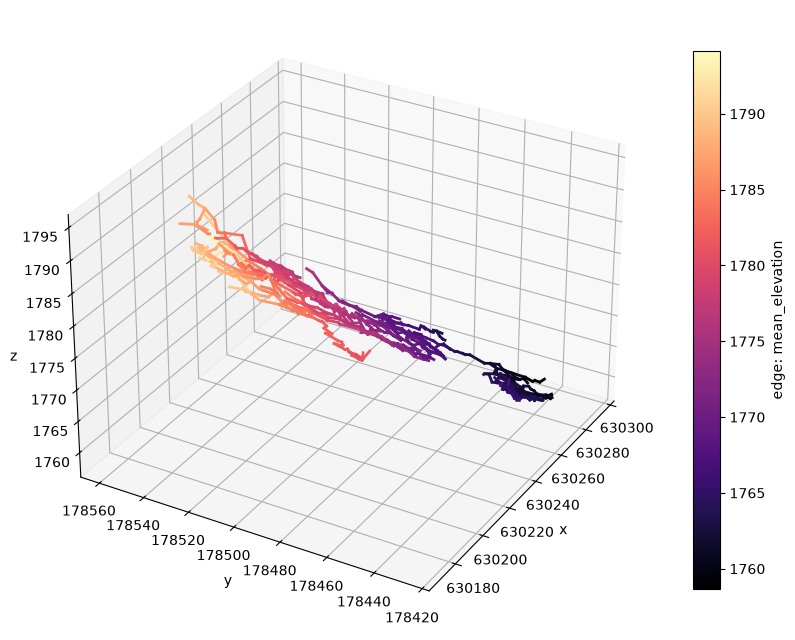

In [31]:
# Plot 3D (matplotlib) - plot an edge property (attribute) 

options_edges = {
    'linestyle' : 'solid',  # edge line style (equivalent key: 'ls')
    'linewidth' : 2,        # edge line width (equivalent key: 'lw')
    'cmap'      : 'magma',  # edge color map (for attribute values)
}

plt.figure(figsize=(10, 10))

kn.view.plot_graph3d(
    g,
    plot_nodes=False, # hide nodes
    edge_attr='mean_elevation',
    options_edges=options_edges,
    options_edge_colorbar={'shrink':0.7}
)

plt.show()


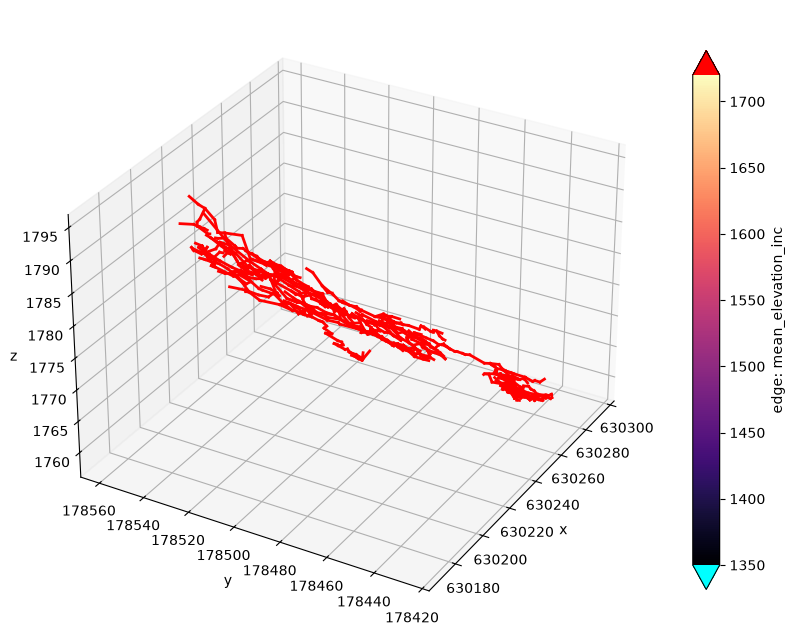

In [32]:
# Plot 3D (matplotlib) - plot an edge property (attribute) with missing data (nan) - customize color 

# Color map for edge attribute
cmap = plt.get_cmap('magma')
cmap.set_over('red')        # color for value above upper limit 'vmax' (if specified)
cmap.set_under('cyan')      # color for value below lower limit 'vmin' (if specified)
cmap.set_bad('palegreen')   # color for nan value (missing data) / will be overwritten by 'edge_color' (if specified)

options_edges = {
    'linestyle' : 'solid',  # edge line style (equivalent key: 'ls')
    'linewidth' : 2,        # edge line width (equivalent key: 'lw')
    # 'color'     : 'gray',   # edge color (overwrite "bad color" of cmap)
    'cmap'      : cmap,     # edge color map (for attribute values)
    'vmin'   : 1350,        # min value for color map (edge)
    'vmax'   : 1720,        # max value for color map (edge)
}

plt.figure(figsize=(10, 10))

kn.view.plot_graph3d(
    g,
    plot_nodes=False, # hide nodes
    edge_attr='mean_elevation_inc',
    options_edges=options_edges,
    options_edge_colorbar={'shrink':0.7, 'extend': 'both'}
)

plt.show()


### Plot in 3D (matplotlib) - plot node and edge properties (attributes)

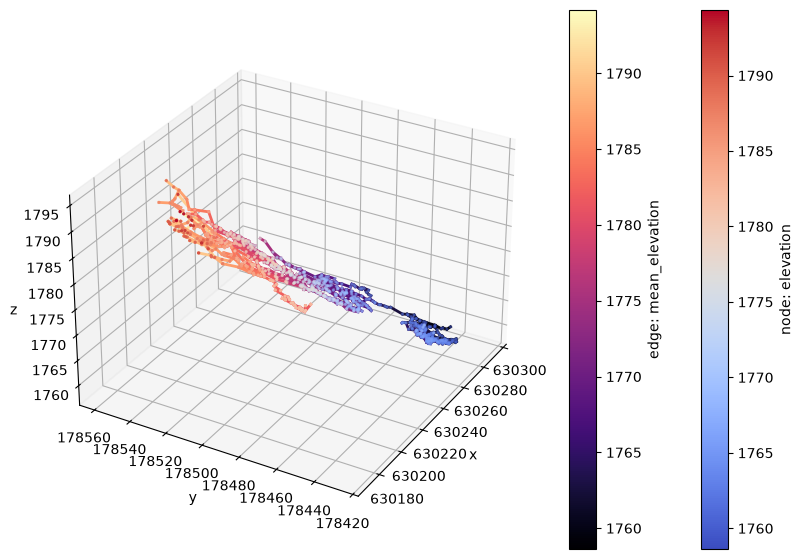

In [33]:
# Plot 3D (matplotlib) - plot node and edge properties (attributes)

options_nodes = {
    's'      : 2,           # node size
    'cmap'   : 'coolwarm',  # node color map (for attribute values)
}

options_edges = {
    'linestyle' : 'solid',  # edge line style (equivalent key: 'ls')
    'linewidth' : 2,        # edge line width (equivalent key: 'lw')
    'cmap'      : 'magma',  # edge color map (for attribute values)
}

plt.figure(figsize=(10, 10))

kn.view.plot_graph3d(
    g,
    node_attr='elevation',
    edge_attr='mean_elevation',
    options_nodes=options_nodes,
    options_edges=options_edges,
    options_node_colorbar={'shrink':0.7},
    options_edge_colorbar={'shrink':0.7}
)

plt.show()


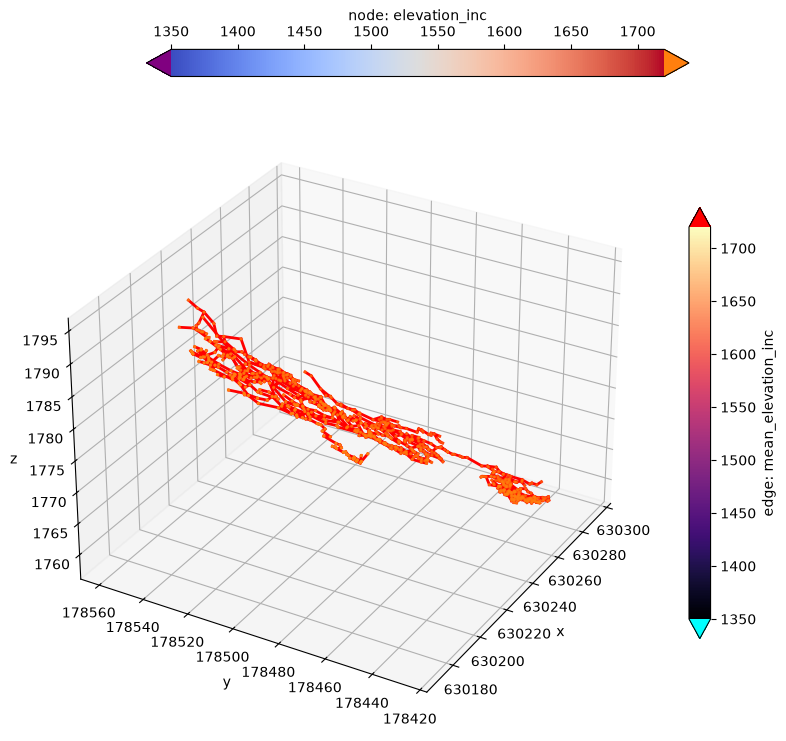

In [34]:
# Plot 3D (matplotlib)- plot node and edge properties with missing data (nan) - customize color 

# Color map for node attribute
cmap = plt.get_cmap('coolwarm')
cmap.set_over('tab:orange') # color for value above upper limit 'vmax' (if specified)
cmap.set_under('purple')    # color for value below lower limit 'vmin' (if specified)
cmap.set_bad('lime')        # color for nan value (missing data) / will be overwritten by 'color' (if specified)

options_nodes = {
    's'      : 2,           # node size
    # 'color'  : 'tab:blue',  # node color (overwrite "bad color" of cmap)
    'cmap'   : cmap,        # node color map (for attribute values)
    'vmin'   : 1350,        # min value for color map (node)
    'vmax'   : 1720,        # max value for color map (node)
}

# Color map for edge attribute
cmap = plt.get_cmap('magma')
cmap.set_over('red')        # color for value above upper limit 'vmax' (if specified)
cmap.set_under('cyan')      # color for value below lower limit 'vmin' (if specified)
cmap.set_bad('palegreen')   # color for nan value (missing data) / will be overwritten by 'edge_color' (if specified)

options_edges = {
    'linestyle' : 'solid',  # edge line style (equivalent key: 'ls')
    'linewidth' : 2,        # edge line width (equivalent key: 'lw')
    # 'color'     : 'gray',   # edge color (overwrite "bad color" of cmap)
    'cmap'      : cmap,     # edge color map (for attribute values)
    'vmin'   : 1350,        # min value for color map (edge)
    'vmax'   : 1720,        # max value for color map (edge)
}

plt.figure(figsize=(10, 10))

kn.view.plot_graph3d(
    g,
    node_attr='elevation_inc',
    edge_attr='mean_elevation_inc',
    options_nodes=options_nodes,
    options_edges=options_edges,
    options_node_colorbar={'shrink':0.7, 'extend':'both', 'location':'top'},
    options_edge_colorbar={'shrink':0.7, 'extend':'both'},
    # aspect_equal=True, # same scale for each axis
)

plt.show()


### Plot in 3D (matplotlib) - in principal axes (from PCA)

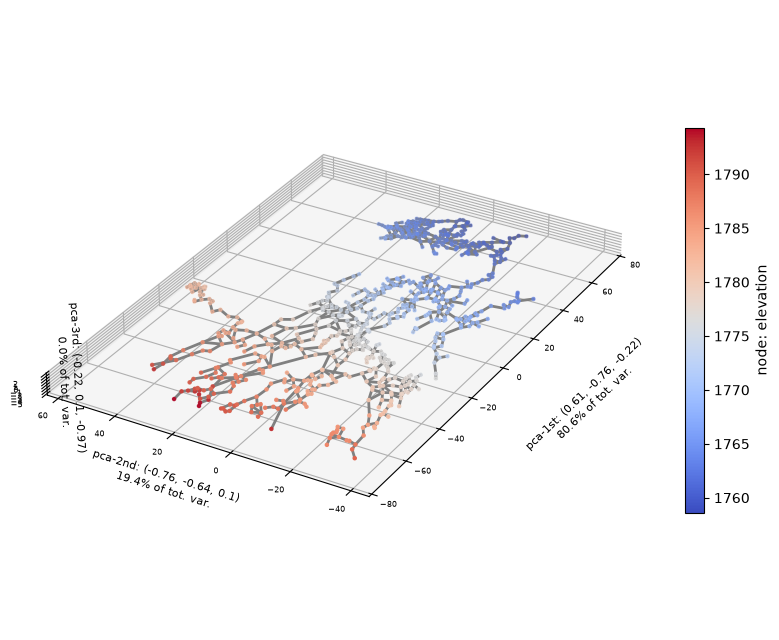

In [35]:
# Plot 3D (matplotlib)- plot in principal axes (from PCA)
# - (plot a node property (attribute))

options_nodes = {
    's'      : 5,           # node size
    'cmap'   : 'coolwarm',  # node color map (for attribute values)
}

options_edges = {
    'linestyle' : 'solid',  # edge line style (equivalent key: 'ls')
    'linewidth' : 2,        # edge line width (equivalent key: 'lw')
    'color'     : 'gray',   # edge color
}

plt.figure(figsize=(10, 10))

kn.view.plot_graph3d(
    g,
    mode='pca',     # coordinates in principal axes system
    centering=True, # centering coordinates (mean equals zero)
    node_attr='elevation',
    options_nodes=options_nodes,
    options_edges=options_edges,
    options_node_colorbar={'shrink':0.5},
    options_xlabel={'fontsize':8, 'labelpad':40},
    options_ylabel={'fontsize':8, 'labelpad':10},
    options_zlabel={'fontsize':8, 'labelpad':-30},
    options_xaxis_ticks={'labelsize':6},
    options_yaxis_ticks={'labelsize':6},
    options_zaxis_ticks={'labelsize':6},
    aspect_equal=True # same scale for each axis
)

plt.show()


### Plot in 3D (matplotlib) - multiple plots

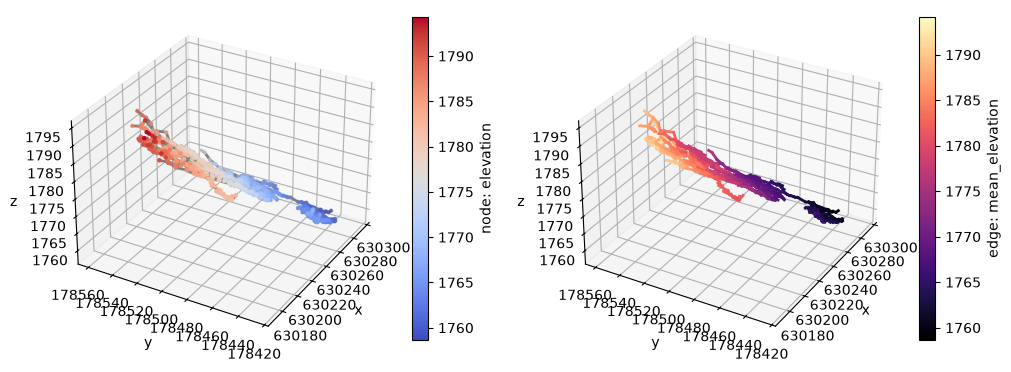

In [36]:
# Plot in 3D (matplotlib) - multiple plots
# - 1st subplot: plot a node property
# - 2nd subplot: plot an edge property

# Options for 1st subplot
options_nodes_1 = {
    's'      : 5,                # node size
    'cmap'        : 'coolwarm',  # node color map (for attribute values)
}

options_edges_1 = {
    'linestyle' : 'solid',  # edge line style (equivalent key: 'ls')
    'linewidth' : 2,        # edge line width (equivalent key: 'lw')
    'color'     : 'gray',   # edge color
}

# Options for 2nd subplot
options_edges_2 = {
    'linestyle' : 'solid',  # edge line style (equivalent key: 'ls')
    'linewidth' : 2,        # edge line width (equivalent key: 'lw')
    'cmap'      : 'magma',  # edge color map (for attribute values)
}


fig = plt.figure(figsize=(12, 6))

ax = fig.add_subplot(1, 2, 1, projection='3d')
kn.view.plot_graph3d(
    g,
    ax=ax,
    node_attr='elevation',
    options_nodes=options_nodes_1,
    options_edges=options_edges_1,
    options_node_colorbar={'shrink':0.7},
)

ax = fig.add_subplot(1, 2, 2, projection='3d')
kn.view.plot_graph3d(
    g,
    ax=ax,
    plot_nodes=False,
    edge_attr='mean_elevation',
    options_edges=options_edges_2,
    options_edge_colorbar={'shrink':0.7}
)

plt.show()


## Plot 3D - based on `pyvista`

The method `pv_plot` of a `karstnet.KGraph` object, or the function `karstnet.view.pv_plot_graph`, allows to plot the original (or simplified) graph in 3D using `pyvista`.

The plot is done by using the function `pyvista.add_mesh` for plotting nodes and edges; options can be specified by respectively the parameters `options_nodes` and `options_edges` (dictionaries).

Principal component analysis (PCA) can be applied to plot the graph in the principal axes system (parameter `mode`).

Some examples are shown below; see the docs of the function `karstnet.view.pv_plot_graph` for more details.

### Plot in 3D (pyvista) (no node / edge property)

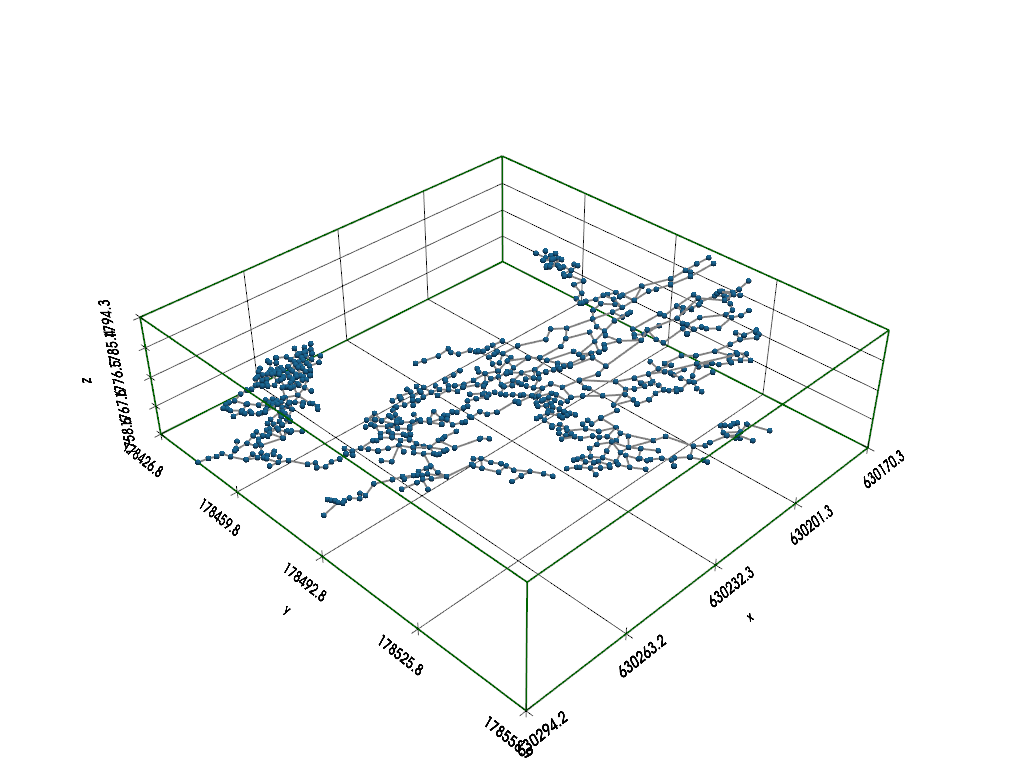

In [37]:
# Plot 3D (pyvista) (no node / edge property)
options_nodes = {
    'point_size' : 6,           # node size
    'color'      : 'tab:blue',  # node color
}

options_edges = {
    'line_width' : 2,         # edge line width
    'color'      : 'gray',    # edge color
}

# pp = pv.Plotter(notebook=False) # plot in a pop-up window
pp = pv.Plotter()

kn.view.pv_plot_graph(
    g, 
    plotter=pp,
    plot_nodes=True, # default is True; set to False to hide nodes
    plot_edges=True, # default is True; set to False to hide edges
    options_nodes=options_nodes,
    options_edges=options_edges,
    show_grid=True,
    options_show_grid={'font_size':12, 'padding':0.2},
    show_outline=True,
    options_show_outline={'line_width':2, 'color':'darkgreen'},
    with_labels=False
)
# # OR:
# kg.pv_plot(    
#     plotter=pp,
#     options_nodes=options_nodes,
#     options_edges=options_edges,
#     show_grid=True,
#     options_show_grid={'font_size':12, 'padding':0.2},
#     show_outline=True,
#     options_show_outline={'line_width':2, 'color':'darkgreen'},
#     with_labels=False
# )

pp.show()
# cpos = pp.show(return_cpos=True) # useful if plot in a pop-up window, for setting the camera position `cpos`


### Plot in 3D (pyvista) - plot a node property (attribute)

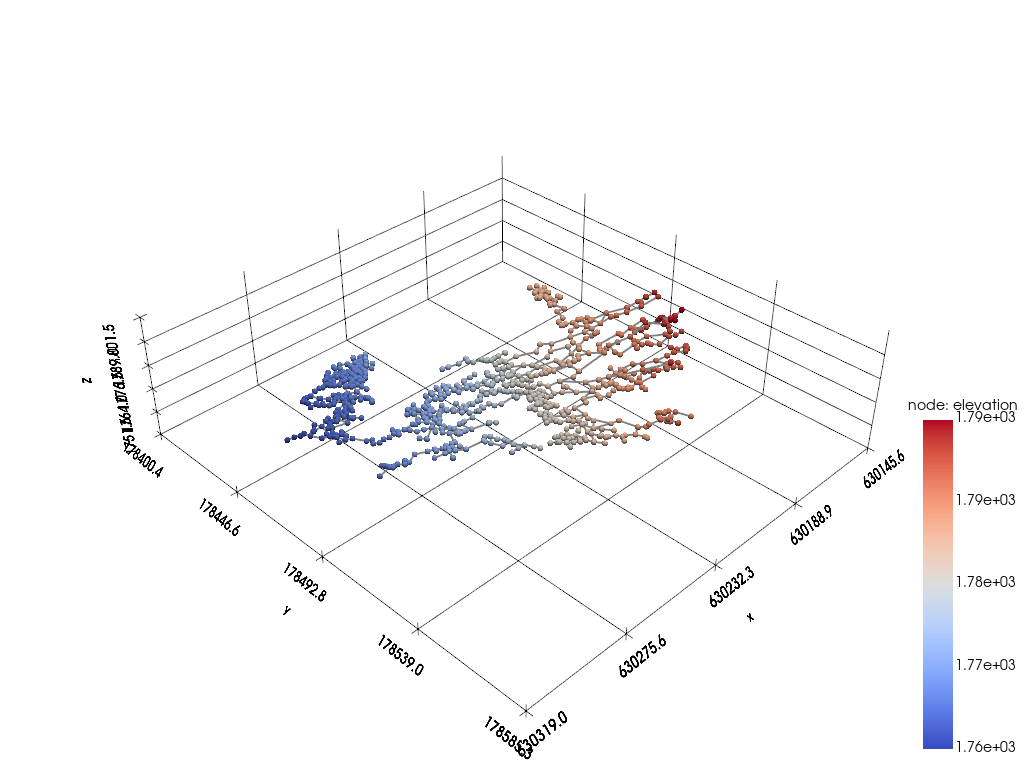

In [38]:
# Plot 3D (pyvista) - plot a node property (attribute)
options_nodes = {
    'point_size' : 6,           # node size
    'cmap'       : 'coolwarm',  # node color map
}

options_edges = {
    'line_width' : 2,         # edge line width
    'color'      : 'gray',    # edge color
}

# pp = pv.Plotter(notebook=False) # plot in a pop-up window
pp = pv.Plotter()
kn.view.pv_plot_graph(
    g, 
    plotter=pp,
    node_attr='elevation',
    options_nodes=options_nodes,
    options_edges=options_edges,
    options_node_colorbar={'title_font_size':14, 'label_font_size':14, 'vertical':True},
    show_grid=True,
    options_show_grid={'font_size':12, 'padding':0.2},
    # show_outline=True,
    # options_show_outline={'line_width':2, 'color':'darkgreen'},
    with_labels=False
)

pp.show()


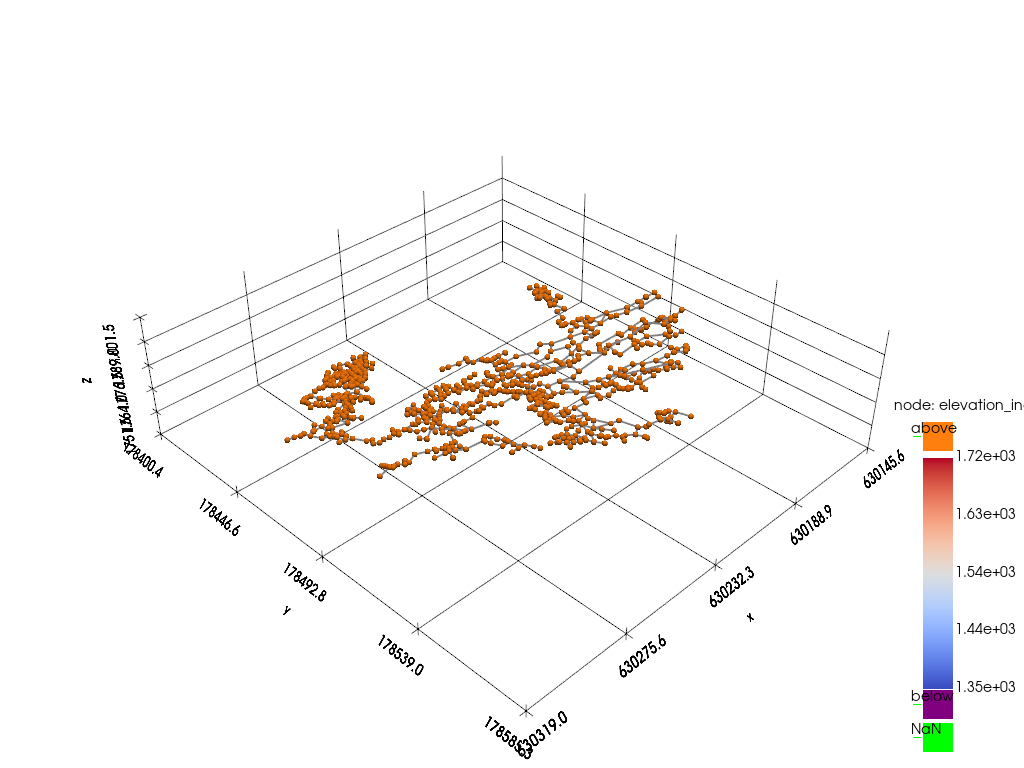

In [39]:
# Plot 3D (pyvista) - plot a node property (attribute) with missing data (nan) - customize color 

# Color map for node attribute
cmap = plt.get_cmap('coolwarm')
cmap.set_over('tab:orange') # color for value above upper limit 'vmax' (if specified) / will be overwritten by 'above_color' (if specified)
cmap.set_under('purple')    # color for value below lower limit 'vmin' (if specified) / will be overwritten by 'below_color' (if specified)
cmap.set_bad('lime')        # color for nan value (missing data) / will be overwritten by 'color' (if specified)
                            # / will be overwritten by 'nan_color' (if specified)

options_nodes = {
    'point_size'  : 6,           # node size
    # 'color'       : 'tab:blue',  # node color (overwrite "bad color" of cmap)
    # 'nan_color'   : 'tab:blue',  # node color for nan value (overwrite "bad color" of cmap)
    'cmap'        : cmap,        # node color map (for attribute values)
    'vmin'        : 1350,        # min value for color map (node)
    'vmax'        : 1720,        # max value for color map (node)
                                 # (also possible 'clim':[min, max])
    # 'above_color' : 'tab:blue',  # node color for above value (overwrite "over color" of cmap)
    # 'below_color' : 'tab:blue',  # node color for below value (overwrite "under color" of cmap)
}

options_edges = {
    'line_width' : 2,         # edge line width
    'color'      : 'gray',    # edge color
}

# pp = pv.Plotter(notebook=False) # plot in a pop-up window
pp = pv.Plotter()
kn.view.pv_plot_graph(
    g, 
    plotter=pp,
    node_attr='elevation_inc',
    options_nodes=options_nodes,
    options_edges=options_edges,
    options_node_colorbar={'title_font_size':14, 'label_font_size':14, 'vertical':True, 'nan_annotation':True},
    show_grid=True,
    options_show_grid={'font_size':12, 'padding':0.2},
    # show_outline=True,
    # options_show_outline={'line_width':2, 'color':'darkgreen'},
    with_labels=False
)

pp.show()


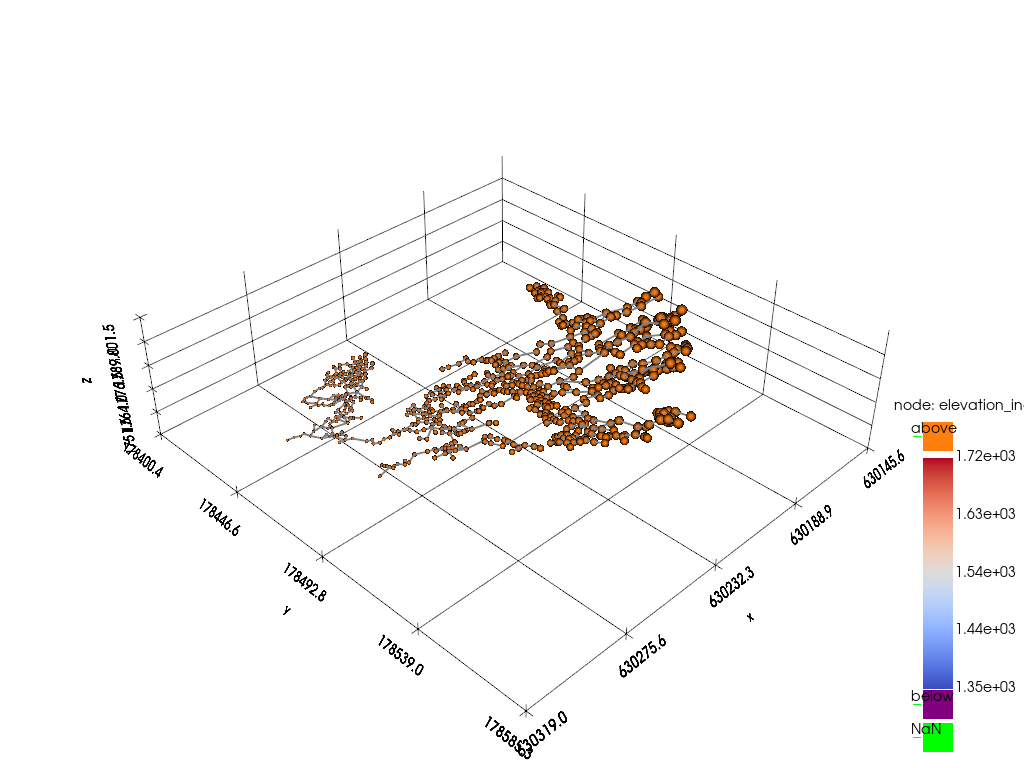

In [48]:
# Plot 3D (pyvista) - plot a node property (attribute) with missing data (nan) - customize color 

# Color map for node attribute
cmap = plt.get_cmap('coolwarm')
cmap.set_over('tab:orange') # color for value above upper limit 'vmax' (if specified) / will be overwritten by 'above_color' (if specified)
cmap.set_under('purple')    # color for value below lower limit 'vmin' (if specified) / will be overwritten by 'below_color' (if specified)
cmap.set_bad('lime')        # color for nan value (missing data) / will be overwritten by 'color' (if specified)
                            # / will be overwritten by 'nan_color' (if specified)

# Set custom node size according to the node property
a = nx.get_node_attributes(g, 'elevation_inc', default=np.nan)
a = np.asarray(list(a.values()))
a_min = np.nanmin(a)
a_max = np.nanmax(a)
size_min = 0.5
size_max = 2
size_nan = 0
t = (size_max - size_min) / (a_max - a_min)
node_size = np.full(g.number_of_nodes(), size_nan, dtype=float)
node_size[~np.isnan(a)] = size_min + (a[~np.isnan(a)] - a_min) * t

options_nodes = {
    'point_size'  : node_size,     # node size
    # 'color'       : 'tab:blue',  # node color (overwrite "bad color" of cmap)
    # 'nan_color'   : 'tab:blue',  # node color for nan value (overwrite "bad color" of cmap)
    'cmap'        : cmap,        # node color map (for attribute values)
    'vmin'        : 1350,        # min value for color map (node)
    'vmax'        : 1720,        # max value for color map (node)
                                 # (also possible 'clim':[min, max])
    # 'above_color' : 'tab:blue',  # node color for above value (overwrite "over color" of cmap)
    # 'below_color' : 'tab:blue',  # node color for below value (overwrite "under color" of cmap)
}

options_edges = {
    'line_width' : 2,         # edge line width
    'color'      : 'gray',    # edge color
}

# pp = pv.Plotter(notebook=False) # plot in a pop-up window
pp = pv.Plotter()
kn.view.pv_plot_graph(
    g, 
    plotter=pp,
    node_attr='elevation_inc',
    options_nodes=options_nodes,
    options_edges=options_edges,
    options_node_colorbar={'title_font_size':14, 'label_font_size':14, 'vertical':True, 'nan_annotation':True},
    show_grid=True,
    options_show_grid={'font_size':12, 'padding':0.2},
    # show_outline=True,
    # options_show_outline={'line_width':2, 'color':'darkgreen'},
    with_labels=False
)

pp.show()


### Plot in 3D (pyvista) - plot an edge property (attribute)

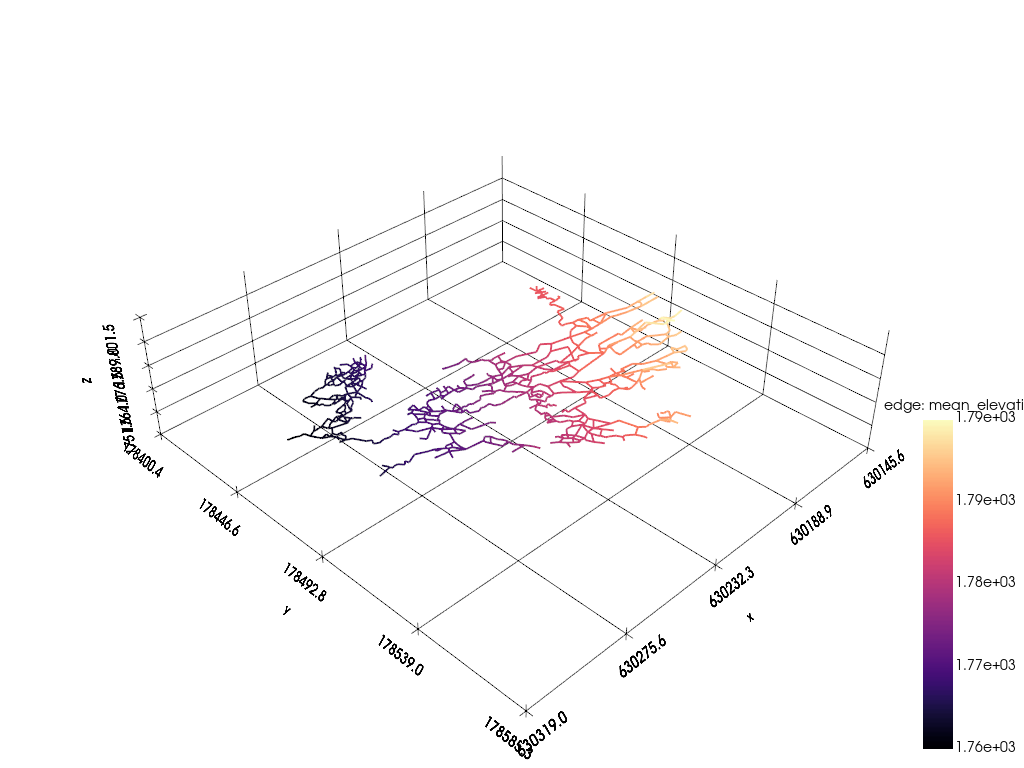

In [41]:
# Plot 3D (pyvista) - plot an edge property (attribute) 

options_edges = {
    'line_width' : 2,         # edge line width
    'cmap'      : 'magma',    # edge color map (for attribute values)
}

# pp = pv.Plotter(notebook=False) # plot in a pop-up window
pp = pv.Plotter()
kn.view.pv_plot_graph(
    g, 
    plotter=pp,
    plot_nodes=False, # hide nodes
    edge_attr='mean_elevation',
    options_edges=options_edges,
    options_edge_colorbar={'title_font_size':14, 'label_font_size':14, 'vertical':True},
    show_grid=True,
    options_show_grid={'font_size':12, 'padding':0.2},
    # show_outline=True,
    # options_show_outline={'line_width':2, 'color':'darkgreen'},
    with_labels=False
)

pp.show()


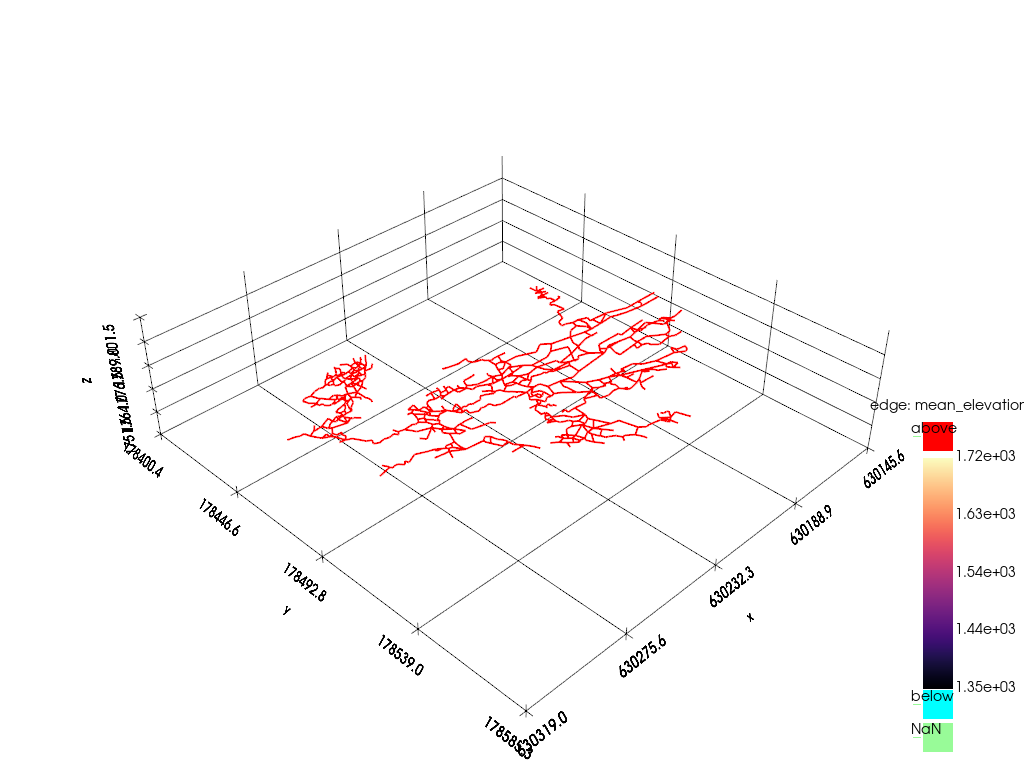

In [42]:
# Plot 3D (pyvista) - plot an edge property (attribute) with missing data (nan) - customize color 

# Color map for edge attribute
cmap = plt.get_cmap('magma')
cmap.set_over('red')        # color for value above upper limit 'vmax' (if specified) / will be overwritten by 'above_color' (if specified)
cmap.set_under('cyan')      # color for value below lower limit 'vmin' (if specified) / will be overwritten by 'below_color' (if specified)
cmap.set_bad('palegreen')   # color for nan value (missing data) / will be overwritten by 'color' (if specified)
                            # / will be overwritten by 'nan_color' (if specified)

options_edges = {
    'line_width'  : 2,           # edge line width
    # 'nan_color'  : 'gray',   # edge color for nan value (overwrite "bad color" of cmap)
    # 'color'      : 'gray',   # edge color (overwrite "bad color" of cmap)
    'cmap'        : cmap,        # edge color map (for attribute values)
    'vmin'        : 1350,        # min value for color map (node)
    'vmax'        : 1720,        # max value for color map (node)
                                 # (also possible 'clim':[min, max]) 
    # 'above_color' : 'gray',  # node color for above value (overwrite "over color" of cmap)
    # 'below_color' : 'gray',  # node color for below value (overwrite "under color" of cmap)
}

# pp = pv.Plotter(notebook=False) # plot in a pop-up window
pp = pv.Plotter()
kn.view.pv_plot_graph(
    kg.graph, 
    plotter=pp,
    plot_nodes=False, # hide nodes
    edge_attr='mean_elevation_inc',
    options_edges=options_edges,
    options_edge_colorbar={'title_font_size':14, 'label_font_size':14, 'vertical':True, 'nan_annotation':True},
    show_grid=True,
    options_show_grid={'font_size':12, 'padding':0.2},
    # show_outline=True,
    # options_show_outline={'line_width':2, 'color':'darkgreen'},
    with_labels=False
)

pp.show()


### Plot in 3D (pyvista) - plot node and edge properties (attributes)

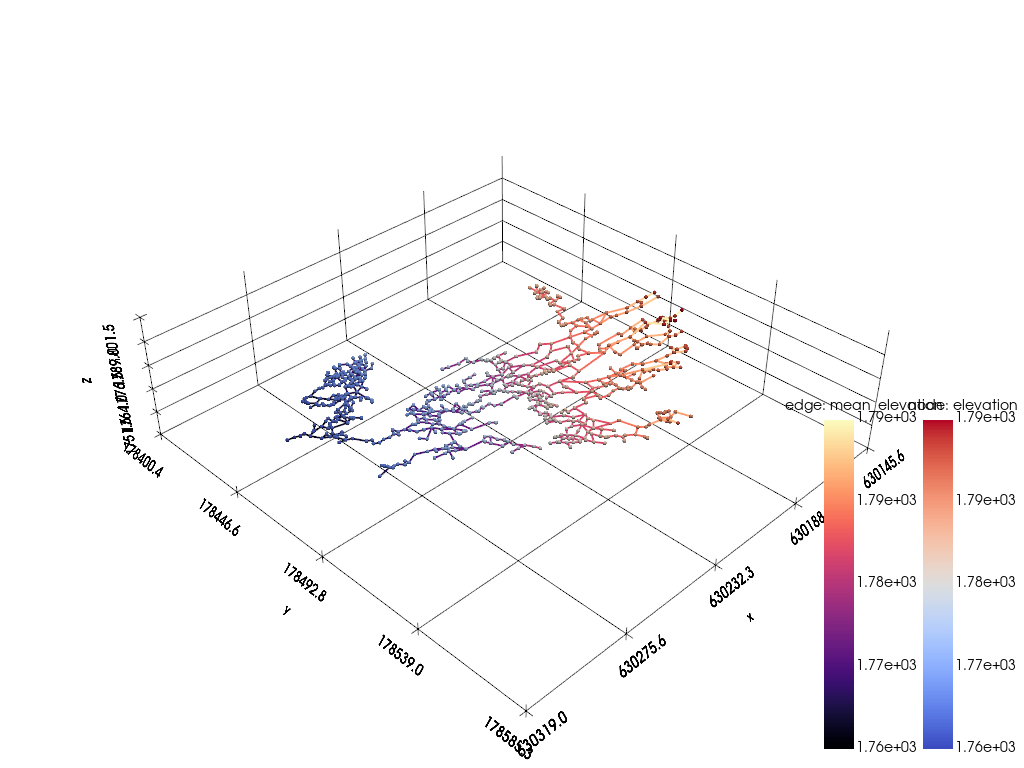

In [43]:
# Plot 3D (pyvista) - plot node and edge properties (attributes)
options_nodes = {
    'point_size' : 4,           # node size
    'cmap'       : 'coolwarm',  # node color map
}

options_edges = {
    'line_width' : 2,         # edge line width
    'cmap'       : cmap,      # edge color map (for attribute values)
}

# pp = pv.Plotter(notebook=False) # plot in a pop-up window
pp = pv.Plotter()
kn.view.pv_plot_graph(
    g, 
    plotter=pp,
    node_attr='elevation',
    edge_attr='mean_elevation',
    options_nodes=options_nodes,
    options_edges=options_edges,
    options_node_colorbar={'title_font_size':14, 'label_font_size':14, 'vertical':True},
    options_edge_colorbar={'title_font_size':14, 'label_font_size':14, 'vertical':True},
    show_grid=True,
    options_show_grid={'font_size':12, 'padding':0.2},
    # show_outline=True,
    # options_show_outline={'line_width':2, 'color':'darkgreen'},
    with_labels=False
)

pp.show()


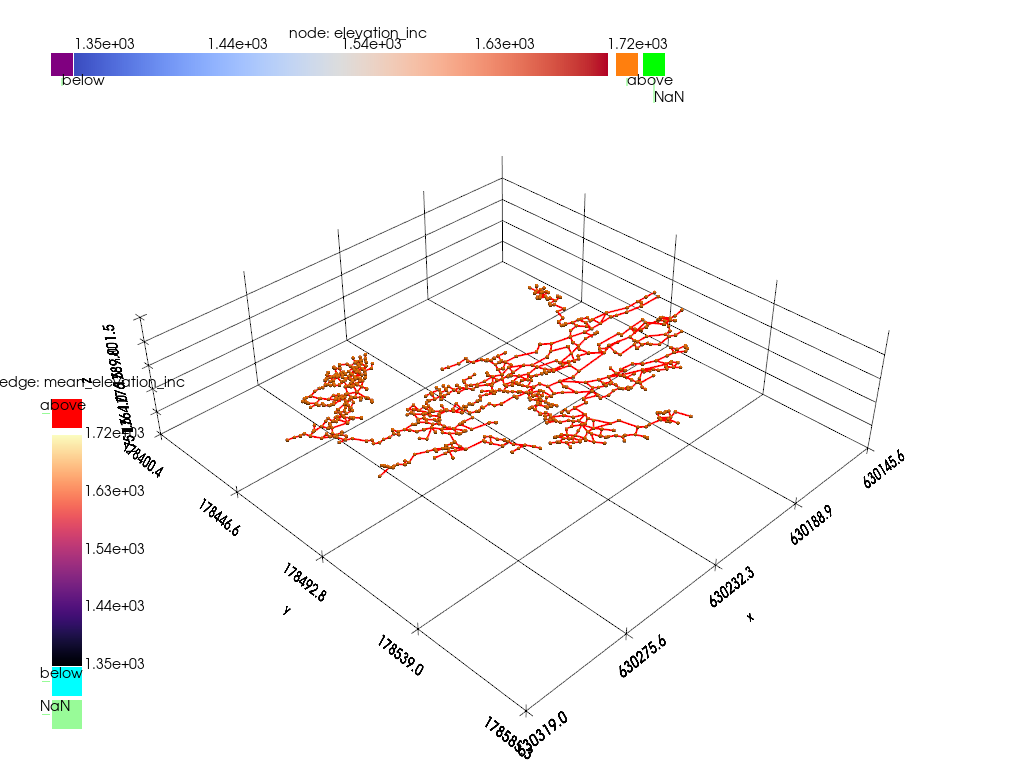

In [44]:
# Plot 3D (pyvista)- plot node and edge properties with missing data (nan) - customize color 

# Color map for node attribute
cmap = plt.get_cmap('coolwarm')
cmap.set_over('tab:orange') # color for value above upper limit 'vmax' (if specified) / will be overwritten by 'above_color' (if specified)
cmap.set_under('purple')    # color for value below lower limit 'vmin' (if specified) / will be overwritten by 'below_color' (if specified)
cmap.set_bad('lime')        # color for nan value (missing data) / will be overwritten by 'color' (if specified)
                            # / will be overwritten by 'nan_color' (if specified)

options_nodes = {
    'point_size'  : 4,           # node size
    # 'color'       : 'tab:blue',  # node color (overwrite "bad color" of cmap)
    # 'nan_color'   : 'tab:blue',  # node color for nan value (overwrite "bad color" of cmap)
    'cmap'        : cmap,        # node color map (for attribute values)
    'vmin'        : 1350,        # min value for color map (node)
    'vmax'        : 1720,        # max value for color map (node)
                                 # (also possible 'clim':[min, max])
    # 'above_color' : 'tab:blue',  # node color for above value (overwrite "over color" of cmap)
    # 'below_color' : 'tab:blue',  # node color for below value (overwrite "under color" of cmap)
}

# Color map for edge attribute
cmap = plt.get_cmap('magma')
cmap.set_over('red')        # color for value above upper limit 'vmax' (if specified) / will be overwritten by 'above_color' (if specified)
cmap.set_under('cyan')      # color for value below lower limit 'vmin' (if specified) / will be overwritten by 'below_color' (if specified)
cmap.set_bad('palegreen')   # color for nan value (missing data) / will be overwritten by 'color' (if specified)
                            # / will be overwritten by 'nan_color' (if specified)

options_edges = {
    'line_width'  : 2,           # edge line width
    # 'nan_color'  : 'gray',   # edge color for nan value (overwrite "bad color" of cmap)
    # 'color'      : 'gray',   # edge color (overwrite "bad color" of cmap)
    'cmap'        : cmap,        # edge color map (for attribute values)
    'vmin'        : 1350,        # min value for color map (node)
    'vmax'        : 1720,        # max value for color map (node)
                                 # (also possible 'clim':[min, max]) 
    # 'above_color' : 'gray',  # node color for above value (overwrite "over color" of cmap)
    # 'below_color' : 'gray',  # node color for below value (overwrite "under color" of cmap)
}

# pp = pv.Plotter(notebook=False) # plot in a pop-up window
pp = pv.Plotter()
kn.view.pv_plot_graph(
    g, 
    plotter=pp,
    node_attr='elevation_inc',
    edge_attr='mean_elevation_inc',
    options_nodes=options_nodes,
    options_edges=options_edges,
    options_node_colorbar={'title_font_size':14, 'label_font_size':14, 'vertical':False, 'nan_annotation':True, 'position_x':0.05, 'position_y':0.90},
    options_edge_colorbar={'title_font_size':14, 'label_font_size':14, 'vertical':True, 'nan_annotation':True, 'position_x':0.05, 'position_y':0.05},
    show_grid=True,
    options_show_grid={'font_size':12, 'padding':0.2},
    # show_outline=True,
    # options_show_outline={'line_width':2, 'color':'darkgreen'},
    with_labels=False
)

pp.show()


### Plot in 3D (pyvista) - in principal axes (from PCA)

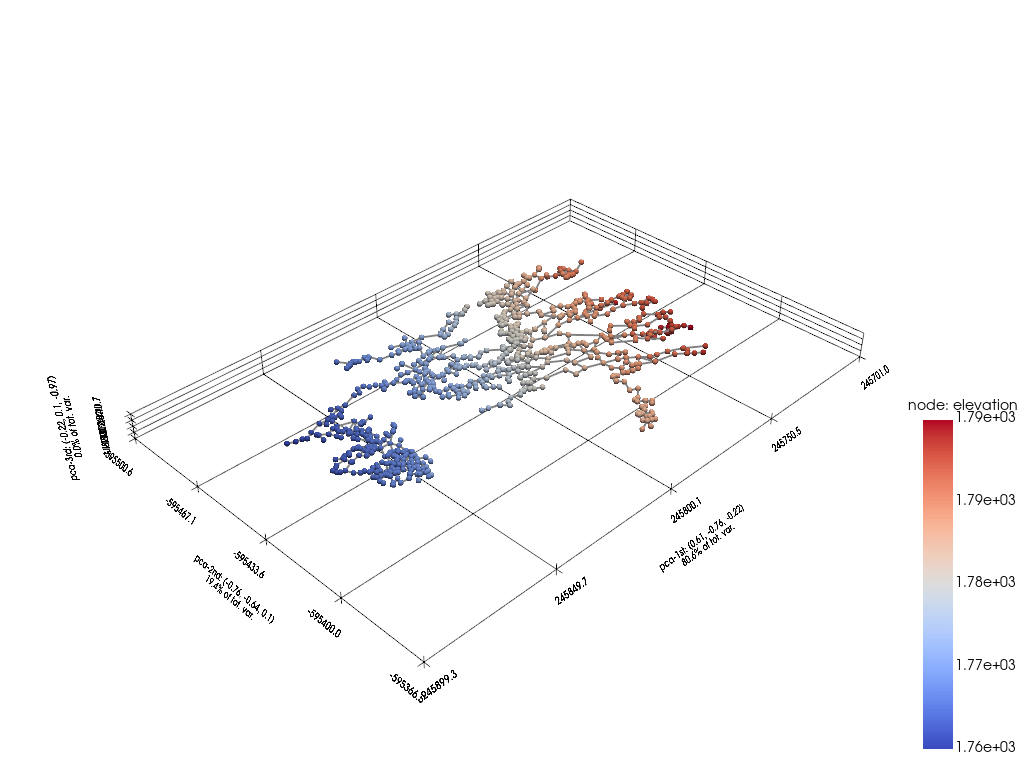

In [45]:
#  Plot 3D (pyvista)- plot in principal axes (from PCA)
# - (plot a node property (attribute))

options_nodes = {
    'point_size' : 6,           # node size
    'cmap'       : 'coolwarm',  # node color map (for attribute values, `cmap.get_cbad()` color is used for nan values if 'color' and 'nan_color' is not specified)
}

options_edges = {
    'line_width' : 2,         # edge line width
    'color'      : 'gray',    # edge color
}

# pp = pv.Plotter(notebook=False) # plot in a pop-up window
pp = pv.Plotter()
kn.view.pv_plot_graph(
    g, 
    plotter=pp,
    mode='pca',
    node_attr='elevation',
    options_nodes=options_nodes,
    options_edges=options_edges,
    options_node_colorbar={'title_font_size':14, 'label_font_size':14, 'vertical':True},
    show_grid=True,
    options_show_grid={'font_size':8, 'padding':0.2},
    # show_outline=True,
    # options_show_outline={'line_width':2, 'color':'darkgreen'},
    with_labels=False
)

pp.show()


### Plot in 3D (pyvista) - multiple plots

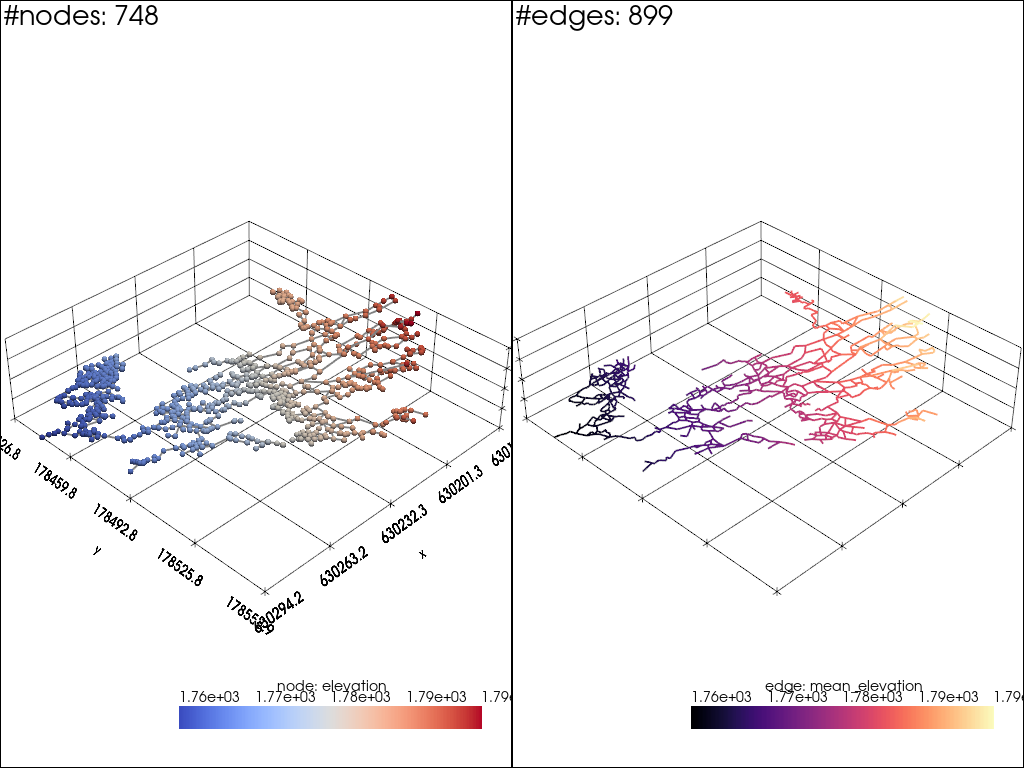

In [46]:
# Plot in 3D (pyvista) - multiple plots
# - 1st subplot: plot a node property
# - 2nd subplot: plot an edge property

# Options for 1st subplot
options_nodes_1 = {
    'point_size' : 6,           # node size
    'cmap'       : 'coolwarm',  # node color map
}

options_edges_1 = {
    'line_width' : 2,         # edge line width
    'color'      : 'gray',    # edge color
}

# Options for 2nd subplot
options_edges_2 = {
    'line_width' : 2,         # edge line width
    'cmap'      : 'magma',    # edge color map (for attribute values)
}

# pp = pv.Plotter(shape=(1, 2), notebook=False) # plot in a pop-up window
pp = pv.Plotter(shape=(1, 2))

pp.subplot(0, 0)
kn.view.pv_plot_graph(
    g, 
    plotter=pp,
    node_attr='elevation',
    options_nodes=options_nodes_1,
    options_edges=options_edges_1,
    options_node_colorbar={'title_font_size':14, 'label_font_size':14, 'vertical':False},
    show_grid=True,
    options_show_grid={'font_size':12, 'padding':0.2},
    # show_outline=True,
    # options_show_outline={'line_width':2, 'color':'darkgreen'},
    with_labels=False
)
pp.add_text(f'#nodes: {g.number_of_nodes()}', font_size=12)

pp.subplot(0, 1)
kn.view.pv_plot_graph(
    g, 
    plotter=pp,
    plot_nodes=False, # hide nodes
    edge_attr='mean_elevation',
    options_edges=options_edges_2,
    options_edge_colorbar={'title_font_size':14, 'label_font_size':14, 'vertical':False},
    show_grid=True,
    options_show_grid={'font_size':12, 'padding':0.2},
    # show_outline=True,
    # options_show_outline={'line_width':2, 'color':'darkgreen'},
    with_labels=False
)
pp.add_text(f'#edges: {g.number_of_edges()}', font_size=12)

pp.link_views()

pp.show()
